# Restricted Boltzmann Machines on MNIST

**Author:** Amirmohammad Saiedi Saber

Implementation and analysis of contrastive divergence, visible-bias initialisation, free-energy barriers, Gibbs-chain mixing, and hyperparameter sensitivity for an RBM trained on binarised MNIST digits.


# Restricted Boltzmann Machine — MNIST

A **Restricted Boltzmann Machine (RBM)** is a two-layer, energy-based generative
model: a layer of *visible* units that carries the data and a layer of *hidden*
units that learns latent features, with **no connections inside a layer**. That
"restriction" is what makes learning tractable — the conditional distributions
factorise, so the model can be trained by alternating sampling between the two
layers.

This notebook trains an RBM on **binarised MNIST digits** $\{0,1,2\}$ and uses it
as a laboratory for studying how RBMs learn and generate.

### What this notebook covers

| Part | Question it answers |
|------|---------------------|
| **1. The RBM notebook** | How does Contrastive Divergence update the weights? |
| **2. Bias initialisation** | Why does Hinton's visible-bias trick speed up training? |
| **3. Energy barriers** | Why does the CD sampler stay stuck on one digit? |
| **4. Hyperparameters** | Which knobs (optimiser, L, $N_t$, $\gamma$, encoding) matter most? |

### Diagnostics used throughout

- **Gradient RMS** — convergence vs. the statistical noise floor
- **Weight filters** — what receptive fields each hidden unit learns
- **Generative Gibbs chains** — can the model dream realistic digits?
- **Free-energy landscapes** — how separated are the digit "basins"?


## Imports



In [1]:
import datetime
import os
import sys
from pathlib import Path

# Resolve repository paths whether Jupyter starts in the root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

FIG_DIR = PROJECT_ROOT / "FIG"
FRAME_DIR = FIG_DIR / "FRAME"
WEIGHTS_DIR = PROJECT_ROOT / "WEIGHTS"
DATA_DIR = PROJECT_ROOT / "DATA"
for directory in (FIG_DIR, FRAME_DIR, WEIGHTS_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# NumPy
import numpy as np
from numpy import exp, sqrt, log, log10, sign, power, cosh, sinh, tanh, floor
rng = np.random.default_rng(12345)
np.set_printoptions(precision=4)

# Matplotlib
import matplotlib as mpl
%matplotlib inline
from matplotlib.ticker import NullFormatter, MaxNLocator
mpl.rcParams.update({"font.size": 12})
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# MNIST loader
from sklearn.datasets import fetch_openml


mkdir: FIG: File exists
mkdir: FIG/FRAME: File exists
mkdir: WEIGHTS: File exists
mkdir: DATA: File exists


In [2]:
from matplotlib.colors import LinearSegmentedColormap, to_rgba


PALETTE = {
    "blue":  "#2563EB", "red":    "#EF4444", "green":  "#10B981",
    "purple":"#8B5CF6", "orange": "#F59E0B", "pink":   "#EC4899",
    "teal":  "#06B6D4", "lime":   "#65A30D", "indigo": "#4F46E5",
    "rose":  "#F43F5E", "slate":  "#334155",
}
CYCLE = [PALETTE[k] for k in
         ("blue","red","green","purple","orange","pink","teal","lime","indigo","rose")]

# diverging colormap for weight filters (vivid blue <-> white <-> red) 
CMAP_W = LinearSegmentedColormap.from_list(
    "vivid_div", ["#1D4ED8", "#60A5FA", "#FFFFFF", "#F87171", "#B91C1C"])
# sequential colormap for digit images (white -> deep indigo "ink") 
CMAP_DIGIT = LinearSegmentedColormap.from_list(
    "ink", ["#FFFFFF", "#C7D2FE", "#6366F1", "#312E81"])

#  global rcParams
plt.rcParams.update({
    "figure.facecolor": "white",   "figure.dpi": 110,
    "savefig.dpi": 150,            "savefig.bbox": "tight",
    "axes.facecolor": "#FBFBFD",   "axes.edgecolor": "#1F2937",
    "axes.linewidth": 1.6,         "axes.grid": True,
    "axes.axisbelow": True,        "axes.labelsize": 12.5,
    "axes.labelweight": "semibold","axes.labelcolor": "#111827",
    "axes.titlesize": 14.5,        "axes.titleweight": "bold",
    "axes.titlepad": 12,           "axes.spines.top": False,
    "axes.spines.right": False,    "axes.prop_cycle": plt.cycler(color=CYCLE),
    "grid.color": "#D1D5DB",       "grid.linewidth": 0.9,
    "grid.alpha": 0.55,            "lines.linewidth": 2.6,
    "lines.markersize": 7.5,       "lines.markeredgewidth": 0.0,
    "xtick.labelsize": 11,         "ytick.labelsize": 11,
    "xtick.color": "#374151",      "ytick.color": "#374151",
    "xtick.major.size": 5,         "ytick.major.size": 5,
    "xtick.major.width": 1.3,      "ytick.major.width": 1.3,
    "legend.fontsize": 10,         "legend.frameon": True,
    "legend.framealpha": 0.95,     "legend.edgecolor": "#D1D5DB",
    "legend.facecolor": "white",   "legend.borderpad": 0.6,
    "font.size": 12,
})

def style_panel(ax, edge=None):
    """Strip ticks/grid from an imshow panel; optional thin coloured frame."""
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for sp in ax.spines.values():
        if edge is None:
            sp.set_visible(False)
        else:
            sp.set_visible(True); sp.set_color(edge); sp.set_linewidth(1.2)

print("Modern-vibrant plotting style loaded.")
print("  PALETTE    :", ", ".join(PALETTE))
print("  CMAP_W     : vivid diverging colormap for weight filters")
print("  CMAP_DIGIT : indigo-ink colormap for digit images")


Modern-vibrant plotting style loaded.
  PALETTE    : blue, red, green, purple, orange, pink, teal, lime, indigo, rose, slate
  CMAP_W     : vivid diverging colormap for weight filters
  CMAP_DIGIT : indigo-ink colormap for digit images


## Load data

We pull the full **MNIST-784** dataset (70 000 handwritten digits, each a
$28\times28 = 784$-pixel greyscale image) from OpenML. Only a subset of digit
classes is kept later; here we just load the raw arrays `X_original` (pixels) and
`Y_original` (labels).


In [3]:
X_original, Y_original = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False,
    data_home=DATA_DIR,
)
print(X_original.shape)


(70000, 784)


## Parameters

The central control panel. The key knobs:

| Symbol | Meaning | Effect |
|--------|---------|--------|
| `Ndigit` | how many digit classes to keep ($0,\dots,N_{digit}-1$) | more classes ⇒ harder, multimodal target |
| `L` | number of hidden units | model capacity / number of latent features |
| `SPINS` | units in $\{-1,+1\}$ vs. $\{0,1\}$ | changes the energy scale (gap of 2 vs. 1) |
| `POTTS` | one-hot hidden encoding | hidden layer becomes a single $L$-state categorical variable |

> **Note.** `SPINS` and `POTTS` are mutually exclusive — POTTS one-hot encoding is
> only defined for the $\{0,1\}$ convention. 

In [5]:
#    CHOICE OF PARAMETERS      

# number of MNIST digits to keep ( Ndigit=3 keeps 0,1,2)
Ndigit=3
# number of hidden units
L = 12
# use (+1,-1) if SPINS, otherwise use bits (1,0)
SPINS=False
# use one-hot encoding in hidden space if POTTS (use only if SPINS=False)
POTTS=False

dname='DATA/'


# x_min =0 if bits, x_min=-1 if SPINS
# level_gap is the difference in values between the max (1) and the min (x_min)
if SPINS:
    x_min=-1
    level_gap=2.
else:
    x_min=0
    level_gap=1.

if POTTS:
    str_simul="RBM_Potts"
    # in one-hot encoding, number of possible hidden states matches L
    Nz=L
else:
    str_simul="RBM"
    # number of possible hidden states: 2**L
    Nz=2**L
    
if POTTS and SPINS: 
    print("\n\n>>>>>>>> WARNING:  POTTS and SPINS cannot coexist\n\n")

## Select data and binarise

An RBM with Bernoulli units needs **binary** inputs, but MNIST pixels are 8-bit
greyscale. We therefore:

1. **Filter** the dataset to the chosen digit classes (`keep` mask).
2. **Threshold** every pixel at 50 % intensity → on/off
   ($1$/$0$ for bits, $+1$/$-1$ for spins).

The helper `MNIST_bit` does the thresholding (and can optionally down-sample
$28\times28 \to 14\times14$). Three galleries are shown: the raw digits, the
class-filtered digits, and the final binarised digits the RBM actually sees.


('0', '1', '2')
dataset with 21770 points, each with 784 bits

first 10 MNIST data points


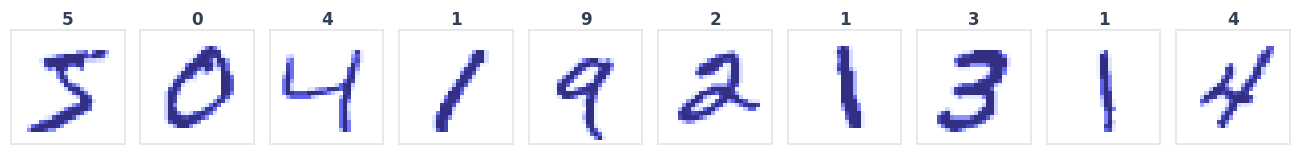

first 10 MNIST-3 data points


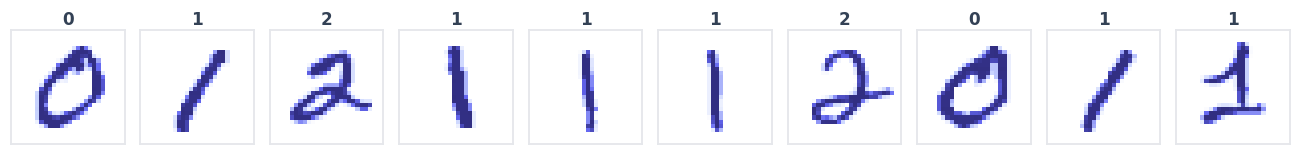

first 10 MNIST-3 data points, binarized


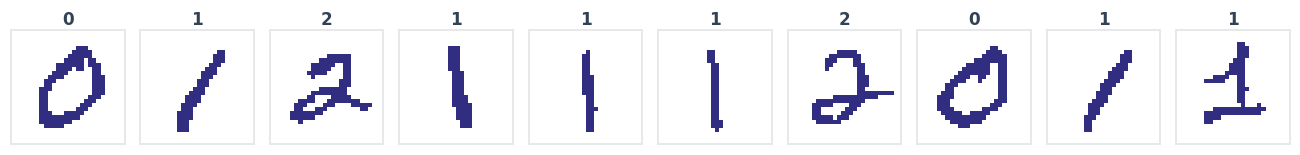

each of Nd=21770 data has D=784 bits


In [6]:
def show_MNIST(x, y=[], z=[], Nex=5, S=1.5, side=0, colors=[]):
    if side==0: side = int(sqrt(x.shape[1]))
    if len(y)<1: y=np.full(Nex,"")
    colors=np.array(colors)
    fig, AX = plt.subplots(1,Nex,figsize=(S*Nex,S*1.13))
    fig.patch.set_facecolor("white")
    if Nex==1: AX=[AX]
    for i, img in enumerate(x[:Nex].reshape(Nex, side, side)):
        if len(colors)==0:
            newcmp = CMAP_DIGIT
        else:
            col= colors[0] + (colors[1]-colors[0])*(i+1)/(Nex+1)
            newcmp = ListedColormap((col,(1,1,1,1)))
        ax=AX[i]
        ax.imshow(img, cmap=newcmp, interpolation="nearest")
        style_panel(ax, edge="#E5E7EB")
        if len(y)>0 and str(y[i])!="":
            ax.set_title(str(y[i]), fontsize=11, fontweight="bold",
                         color=PALETTE["slate"], pad=4)
        if len(z)>0:
            ax.set_title(''.join(map(str, z[i])), fontsize=8,
                         color=PALETTE["slate"], pad=4)
    plt.subplots_adjust(wspace=0.14)
    plt.show()
            
def MNIST_bit(X,side=28,level=0.5):
    NX=len(X)
    print(f"dataset with {NX} points, each with {len(X[0])} bits\n")
    if side==14:
        X = np.reshape(X,(NX,28,28))
        # new value = average over 4 values in a 2x2 square
        Xr = 0.25*(X[:,0::2,0::2]+X[:,1::2,0::2]+X[:,0::2,1::2]+X[:,1::2,1::2])
        X  = Xr.reshape(NX,side**2)
    # binarize data and then convert it to 1/0 or 1/-1
    X = np.where(X/255 > level, 1, x_min)
    return X.astype("int")

list_10_digits = ('0','1','2','3','4','5','6','7','8','9')
list_digits = list_10_digits[:Ndigit]
print(list_digits)
keep=np.isin(Y_original, list_digits)
X_keep,Y=X_original[keep],Y_original[keep]

data,label = MNIST_bit(X_keep),Y
data,label = data.astype("int"),label.astype("int")
print("first 10 MNIST data points")
show_MNIST(X_original, Y_original,Nex=10)
print(f"first 10 MNIST-{Ndigit} data points")
show_MNIST(X_keep, label,Nex=10)
print(f"first 10 MNIST-{Ndigit} data points, binarized")
show_MNIST(data, label,Nex=10)

# number of data points
Nd = len(data)
# number of visible units
D  = len(data[1])

print(f'each of Nd={Nd} data has D={D} bits')

## Data statistics — class balance

Before training, a quick sanity check: **how many examples of each digit do we
have?** A strongly imbalanced dataset would bias the RBM toward the majority
class — its free-energy basin would be deeper simply because it saw more
examples, not because the digit is intrinsically more probable. The bar chart
below confirms the three classes are reasonably balanced, and the gallery shows a
random cross-section of the binarised training data.


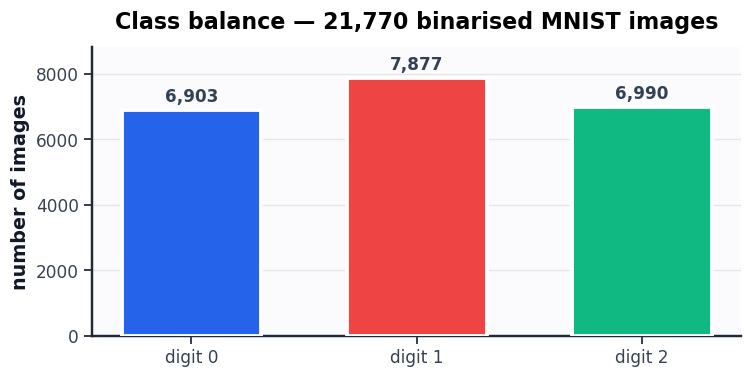

Training-data gallery (binarised digits):


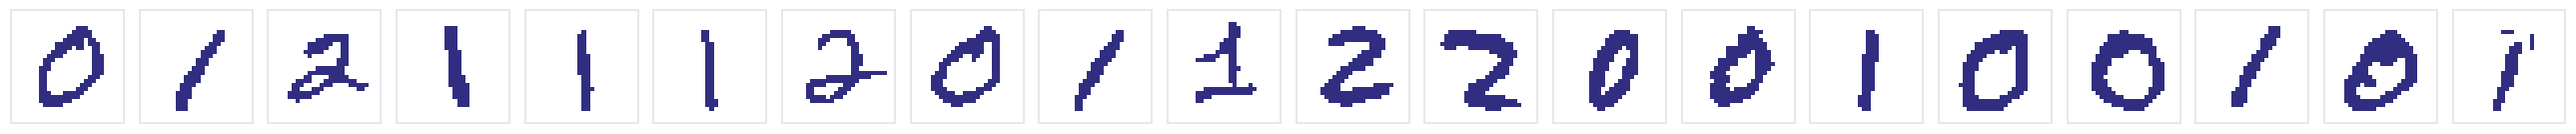

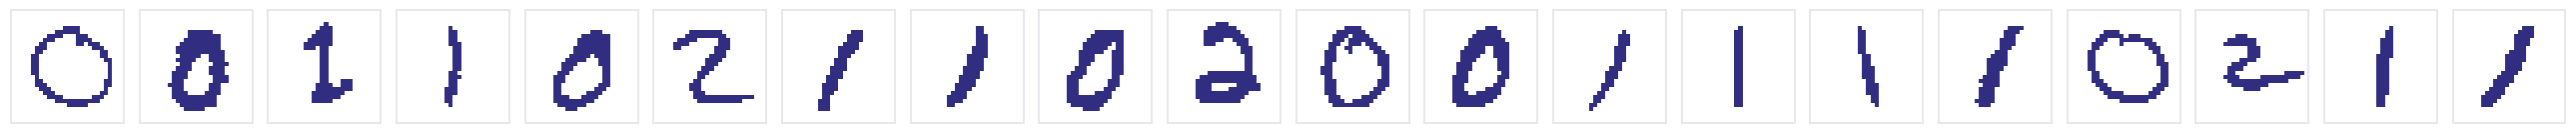

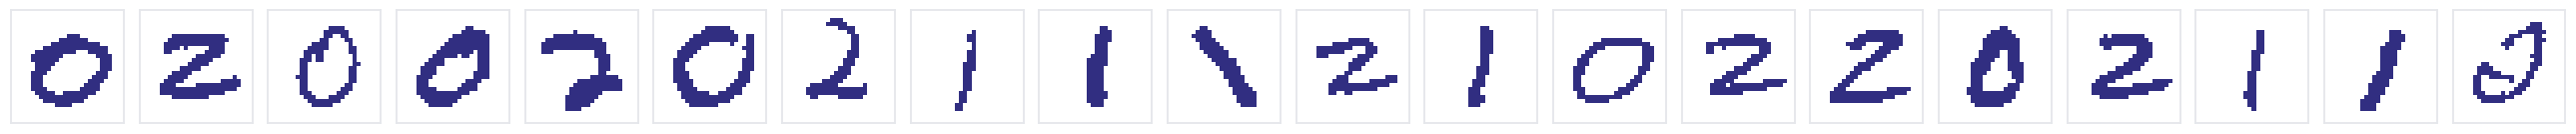

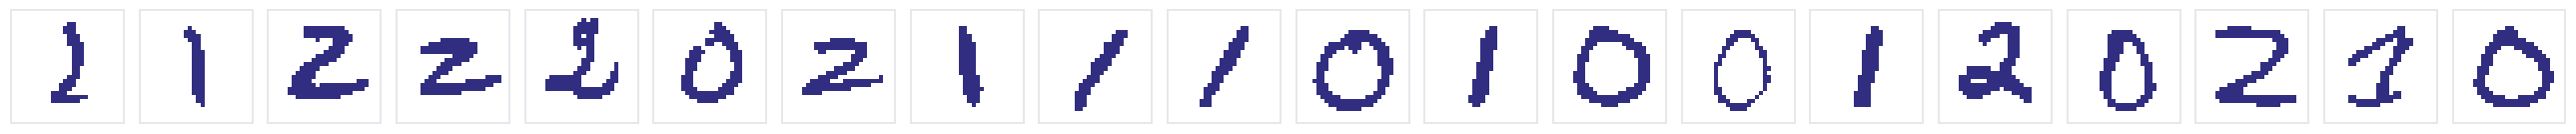

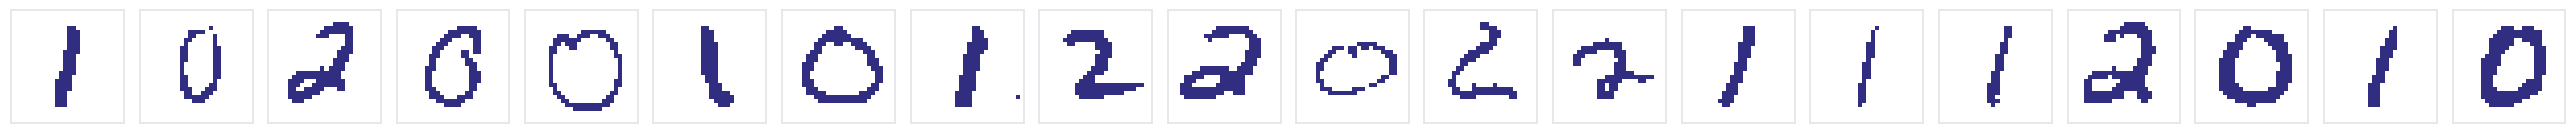

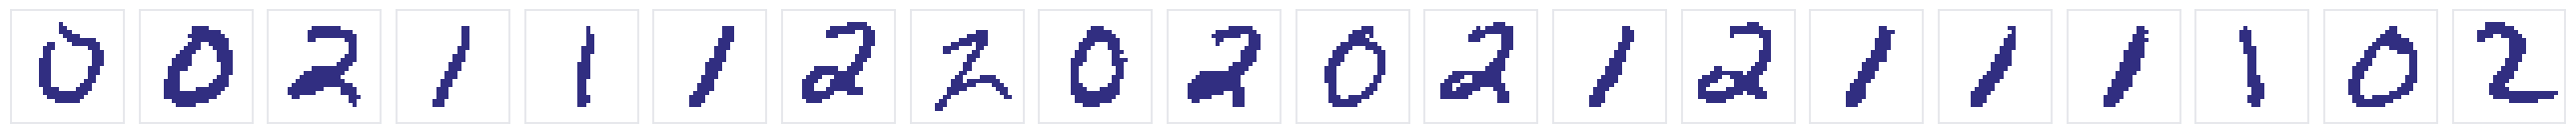

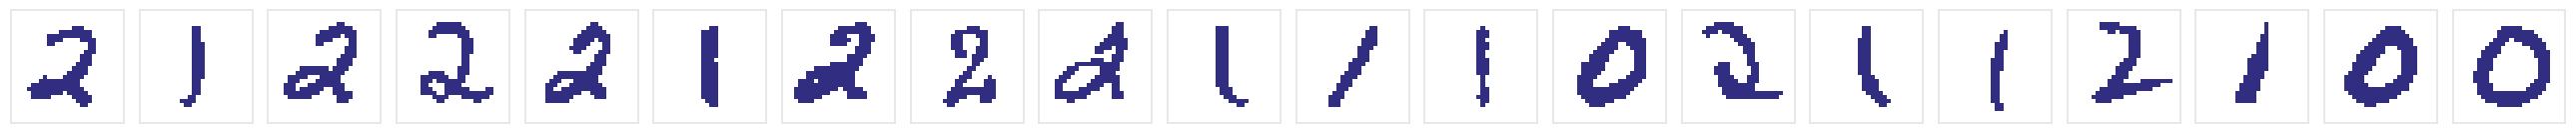

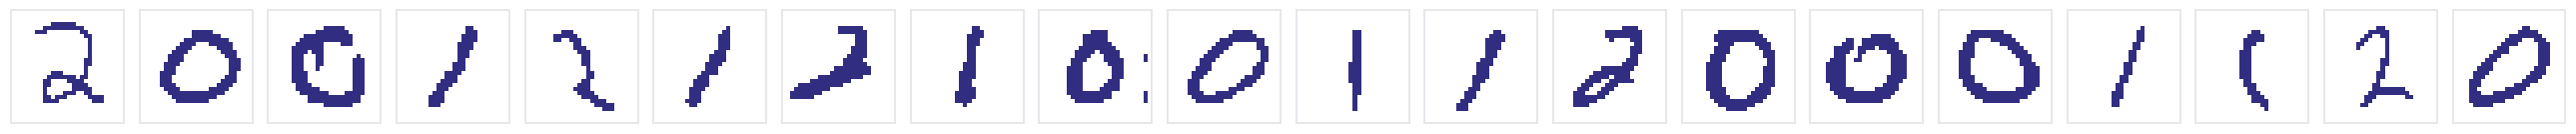

In [7]:
# Class balance of the selected MNIST subset 
fig, ax = plt.subplots(figsize=(7, 3.6))
counts = np.bincount(label, minlength=Ndigit)
bars = ax.bar(np.arange(Ndigit), counts, width=0.62,
              color=[CYCLE[d] for d in range(Ndigit)],
              edgecolor="white", linewidth=2.5, zorder=3)
for d, c in enumerate(counts):
    ax.text(d, c + max(counts)*0.015, f"{c:,}", ha="center", va="bottom",
            fontweight="bold", fontsize=11, color=PALETTE["slate"])
ax.set_xticks(np.arange(Ndigit))
ax.set_xticklabels([f"digit {d}" for d in range(Ndigit)])
ax.set_ylabel("number of images")
ax.set_title(f"Class balance — {Nd:,} binarised MNIST images")
ax.grid(axis="x", visible=False)
ax.margins(y=0.12)
plt.tight_layout(); plt.show()

# A quick gallery of the binarised training data
print("Training-data gallery (binarised digits):")
for i in range(8): show_MNIST(data[i*20:], Nex=20)

## Contrastive Divergence (CD)

### 1 — Energy and the joint distribution

An RBM is a **bipartite, undirected, energy-based model** with

- visible units $\mathbf{x}\in\{0,1\}^D$ — the $D=784$ binarised MNIST pixels,
- hidden units $\mathbf{z}\in\{0,1\}^L$ — the $L$ latent features.

Every joint configuration is assigned an **energy**

$$E(\mathbf{x},\mathbf{z}) \;=\; -\,\mathbf{x}^{\mathsf T}\mathbf{a}
\;-\;\mathbf{z}^{\mathsf T}\mathbf{b}\;-\;\mathbf{x}^{\mathsf T}W\mathbf{z}$$

with visible biases $\mathbf{a}\in\mathbb{R}^D$, hidden biases
$\mathbf{b}\in\mathbb{R}^L$, and weights $W\in\mathbb{R}^{D\times L}$.
The Boltzmann distribution turns energy into probability:

$$P(\mathbf{x},\mathbf{z}) = \frac{1}{Z}\,e^{-E(\mathbf{x},\mathbf{z})},
\qquad Z=\sum_{\mathbf{x},\mathbf{z}} e^{-E(\mathbf{x},\mathbf{z})}.$$

The normaliser $Z$ (the *partition function*) sums over $2^{D+L}$ states — utterly
intractable. This single fact is the reason the whole training algorithm exists.

### 2 — Conditional distributions factorise

Because there are **no intra-layer edges**, conditioning on one layer makes the
other layer's units mutually independent:

$$P(z_j=1\mid\mathbf{x}) = \sigma\!\Big(b_j + \textstyle\sum_i W_{ij}x_i\Big),
\qquad
P(x_i=1\mid\mathbf{z}) = \sigma\!\Big(a_i + \textstyle\sum_j W_{ij}z_j\Big),$$

where $\sigma(u)=1/(1+e^{-u})$. This is the property the word *"restricted"*
refers to, and it is what makes **block Gibbs sampling** possible: a whole layer
can be resampled in one vectorised step. In the code, `H = v_in @ wei + bias` is
the **local field** and `exp(level_gap·H)` the pre-sigmoid activation
(`level_gap` $=2$ for spins, $=1$ for bits).

### 3 — The log-likelihood gradient

Maximising $\log P(\mathbf{x})$ over the data gives the classic two-term gradient

$$\frac{\partial \log P(\mathbf{x})}{\partial W_{ij}}
= \underbrace{\langle x_i z_j\rangle_{\text{data}}}_{\text{positive phase}}
\;-\;
\underbrace{\langle x_i z_j\rangle_{\text{model}}}_{\text{negative phase}}.$$

| Phase | Code term | What it does |
|-------|-----------|--------------|
| **Positive** | `xz_data` | clamp $\mathbf{x}$ to data, sample $\mathbf{z}\sim P(\mathbf{z}\mid\mathbf{x})$ — *lowers* the energy of real data |
| **Negative** | `xz_model` | sample $(\mathbf{x},\mathbf{z})$ from the model itself — *raises* the energy of the model's own fantasies |

Learning stops when the model's fantasies are statistically indistinguishable
from the data — the two terms cancel.

### 4 — The CD-$k$ approximation

The negative phase needs samples from $P(\mathbf{x},\mathbf{z})$, which requires
running a Gibbs chain to **equilibrium** — far too slow. **Contrastive Divergence**
(Hinton, 2002) makes a pragmatic shortcut: start the chain *at a data point* and
run only $k$ steps.

$$\mathbf{x}_{\text{data}}
\;\xrightarrow{\;P(\mathbf z\mid\mathbf x)\;}\; \mathbf{z}_0
\;\xrightarrow{\;P(\mathbf x\mid\mathbf z)\;}\; \mathbf{x}_1
\;\xrightarrow{\;\quad\;}\;\cdots\;\xrightarrow{\;\quad\;}\;
(\mathbf{x}_k,\mathbf{z}_k)$$

$$\Delta W \;\approx\; \eta\,\big(\langle\mathbf{x}_{\text{data}}\,\mathbf{z}_0\rangle
- \langle\mathbf{x}_k\,\mathbf{z}_k\rangle\big).$$

> **Trade-off.** CD-1 is fast but its gradient is *biased* — it never lets the
> chain forget the data. Larger $k$ reduces the bias and gives a better picture
> of the true model distribution, at proportionally higher cost. 


In [8]:
# taking into account energy gap 2 for "spin" variables (-1,1)
def CD_step(v_in,wei,bias,details=False,POTTS=False):

    # local "field"
    H = np.clip(np.dot(v_in, wei) + bias, a_min=-300, a_max=300)
    # "activation"
    a = exp(level_gap*H)
    n = np.shape(H)
    v_out = np.full(n, x_min, dtype=int) # initially, just a list on -1's or 0's
    if POTTS: # RBM with a single hidden unit = 1 (that is, "one-hot encoding" with L states)
        # p: state probability, normalized to 1 over all units=states
        p = a/np.sum(a)
        # F: cumulative probability
        F = np.cumsum(p)
        # pick a state "i" randomly with probability p[i]
        r = np.random.rand()
        i = 0
        while r>F[i]: i+=1
        v_out[i] = 1 # activate a single hidden unit
    else: # normal Ising RBM
        # p: local probability, normalized to 1 for each hidden unit
        p = a / (a + 1.)
        # at each position i, activate the 1's with local probability p[i]
        v_out[np.random.random_sample(n) < p] = 1 

    if details: return v_out,p,a
    else: return v_out

## Weight visualisation — reading the filters

Each column $W_{:,j}$ of the weight matrix has $D=784$ entries — one per visible
pixel. Reshaping it to $28\times28$ turns it into an image: the **receptive
field** of hidden unit $j$.

- **Positive (red) weights** are *excitatory* — ink on those pixels drives
  $z_j\to1$.
- **Negative (blue) weights** are *inhibitory* — ink there suppresses $z_j$.
- A hidden unit therefore acts as a **template matcher**: its activation is large
  when the input image correlates with its weight image.

After training on $\{0,1,2\}$ you typically see a mix of two regimes:

| Filter type | Appearance | Role |
|-------------|------------|------|
| **Stroke detectors** | localised curved / straight pen-strokes | reusable parts shared across digits |
| **Class templates** | whole-digit silhouettes | near-detectors for one specific class |

The top-left panel shows the **visible bias** $\mathbf{a}$: it encodes the average
ink intensity of the data (strongly negative where pixels are almost never on).


In [9]:
def plot_weights_bias(wE, bE, epoch, L,
                      side=0, cols=0, thr=0, s=1.7,
                      title=False, save=True, cmap=None):
    
    if cmap is None: cmap = CMAP_W
    rows = int(np.ceil(L / cols))
    if rows==1: rows=2
    w = wE[epoch]; b = bE[epoch]
    if side==0: side=int(sqrt(len(w)))
    if thr==0: thr=4
    fig, AX = plt.subplots(rows, cols+1, figsize=(s*(1+cols), s*rows))
    fig.patch.set_facecolor("white")
    if title: fig.suptitle(f"epoch = {epoch}", fontsize=15, fontweight="bold")
    k=1
    for i in range(rows):
        for j in range(cols):
            ax = AX[j+1] if rows==1 else AX[i,j+1]
            if k<=L:
                ax.imshow(w[:,k-1].reshape(side, side), cmap=cmap,
                          vmin=-thr, vmax=thr, interpolation="nearest")
                style_panel(ax, edge="#E5E7EB")
                ax.set_title(f"hidden {k}", fontsize=10, fontweight="semibold",
                             color=PALETTE["slate"], pad=4)
            else:
                fig.delaxes(ax)
            k+=1
        if i>0: fig.delaxes(AX[i,0])

    ax = AX[0,0]
    im = ax.imshow(b.reshape(side, side), cmap=cmap, vmin=-thr, vmax=thr,
                   interpolation="nearest")
    style_panel(ax, edge=PALETTE["slate"])
    ax.set_title("visible bias", fontsize=10, fontweight="bold",
                 color=PALETTE["slate"], pad=4)

    # slim colorbar
    cbar_ax = fig.add_axes([0.13, 0.14, 0.02, 0.34])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_edgecolor("#D1D5DB")

    plt.subplots_adjust(hspace=0.32, wspace=0.12)
    if save: plt.savefig(f"./FIG/FRAME/RBM_{epoch}_w-a.png")
    plt.show()
    plt.close()

## Initialisation of Visible Biases — Hinton's Method

### Motivation

At the very start of training every weight W_{ij} is near zero, so the hidden units
carry no information. In that limit the probability the RBM assigns to a visible
unit x_i being **on** depends only on its bias a_i:

    P(x_i = 1) = σ(a_i)            (bits, x ∈ {0,1})
    P(x_i = 1) = σ(2 a_i)          (spins, x ∈ {-1,+1})

where σ(u) = 1 / (1 + e^{−u}) is the sigmoid.

If a_i = 0 (the naive default) the model thinks every pixel is active with
probability 1/2, which is almost never true. MNIST pixels near the image border
are almost always black (p_i ≈ 0), while pixels in the centre of a stroke are
almost always white (p_i ≈ 1). Starting far from the data makes the visible bias
gradient large and wastes the first many epochs just correcting a bad prior.

### Derivation

Hinton's idea: **set a_i so that the model marginal already matches the empirical
pixel frequency p_i before training begins**.

**Step 1 — compute the empirical frequency**

    p_i = (1/N_d) Σ_{k=1}^{N_d} x_i^{(k)}       (mean pixel value in dataset)

For bits this is the fraction of images in which pixel i is on.
For spins this is the mean value in {-1,+1}, so p_i ∈ (−1, +1).

**Step 2 — invert the sigmoid to find a_i**

For **bits** (x ∈ {0,1}), setting σ(a_i) = p_i and solving:

    a_i = σ^{-1}(p_i) = log( p_i / (1 − p_i) )    ← logit function

For **spins** (x ∈ {-1,+1}), the conditional is σ(2 a_i) = p_i:

    a_i = (1/2) · log( p_i / (1 − p_i) )

Both cases are captured by the single formula in the code:

    a_i = (1 / level_gap) · [ log(p_i − x_min) − log(1 − p_i) ]

where `level_gap = 1` for bits and `level_gap = 2` for spins,
and `x_min = 0` for bits, `x_min = -1` for spins.

**Proof that the formula reduces to the logit:**

- *Bits*: x_min=0, level_gap=1
    (1/1) · [log(p_i − 0) − log(1 − p_i)] = log(p_i/(1−p_i))  ✓

- *Spins*: x_min=−1, level_gap=2, and p_i = (x_mean + 1)/2 so x_mean = 2p_i − 1
    (1/2) · [log(x_mean+1) − log(1−x_mean)]
    = (1/2) · [log(2p_i) − log(2(1−p_i))]
    = (1/2) · log(p_i/(1−p_i))  ✓

### Numerical safeguard (clipping)

The logit diverges when p_i → 0 or p_i → 1. Any pixel that is always off or
always on would produce a_i → ±∞. The code clamps p_i to the range
[x_min + ε, 1 − ε] with ε = 10^{−4} before taking the logarithms, keeping
biases finite and training numerically stable.

### Effect on training

| Initialisation | Epoch 0 bias gradient | Convergence |
|---|---|---|
| a = 0 | Large (model far from data) | Slow — many epochs wasted |
| Hinton a_i = logit(p_i) | Near zero (model already ≈ data) | Fast — gradient budget spent on weights |

The visualisation cell below confirms this: the Hinton-initialised biases resemble
the average training image, and the model marginals match the data pixel frequencies
before a single gradient step has been taken.


In [10]:
# initial bias of visible units, based on their average value in the dataset
def Hinton_bias_init(x):
    xmean=np.array(np.mean(x,axis=0))
    # remove values at extrema, to avoid divergences in the log's
    S = 1e-4
    x1,x2 = x_min+S,1-S
    xmean[xmean<x1] = x1
    xmean[xmean>x2] = x2
    return (1/level_gap)*np.clip(log(xmean-x_min) - log(1-xmean),-300,300)
    
# range of each initial weight
sigma = sqrt(4. / float(L + D))

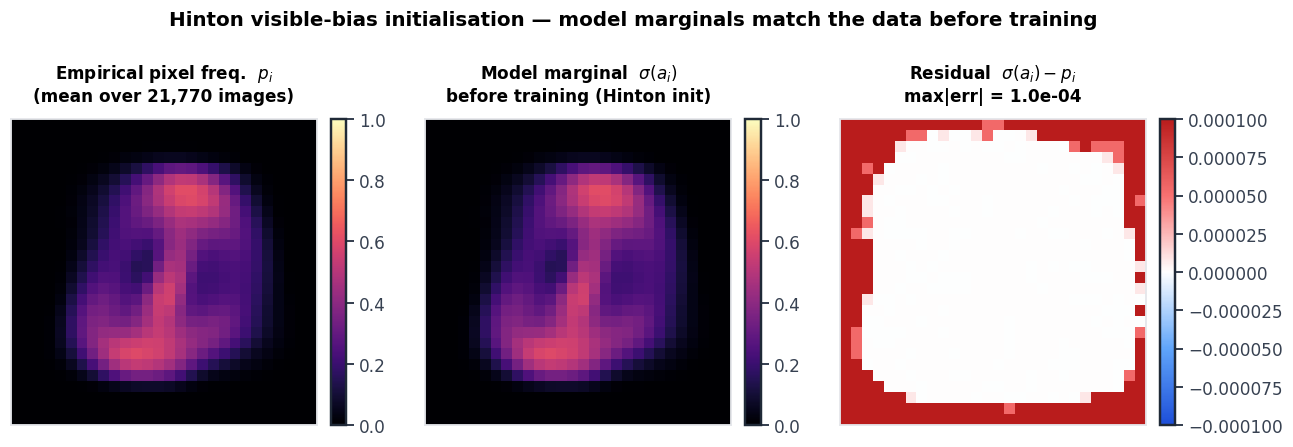

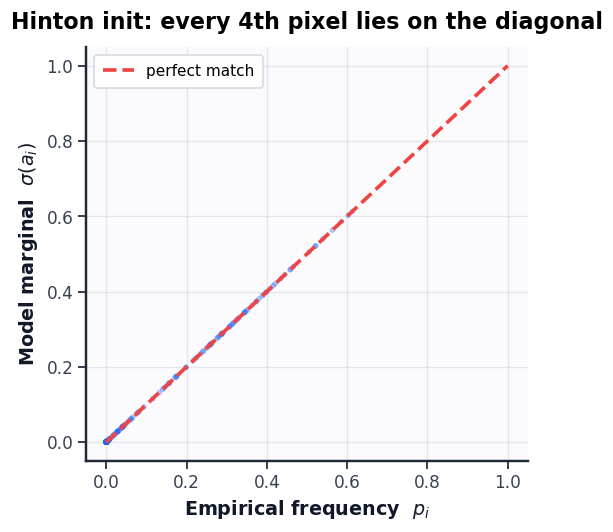

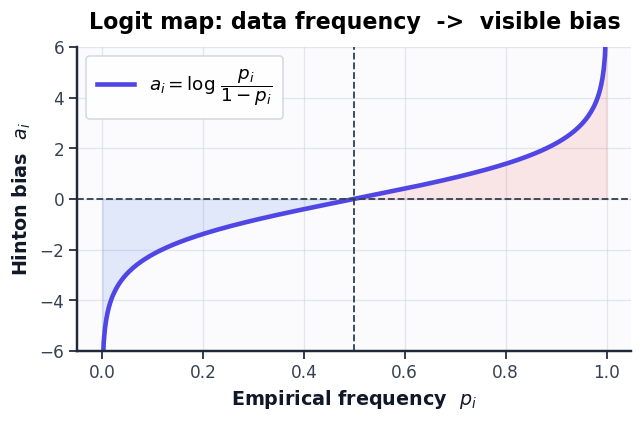

Max absolute mismatch between p_emp and sigma(a_hinton): 1.00e-04
(non-zero only for clamped pixels near 0 or 1)


In [11]:
#  Visualise Hinton initialisation 
# 1. Empirical pixel frequencies
p_emp = np.mean(data, axis=0)          # shape (D,)  values in [x_min, 1]
# 2. Hinton biases (already computed as 'a' in the cell above)
a_hinton = Hinton_bias_init(data)
# 3. Model marginals BEFORE training: P(x_i=1) = sigmoid(level_gap * a_i)
p_model_before = 1. / (1. + np.exp(-level_gap * a_hinton))
diff = p_model_before - p_emp
side = int(np.sqrt(D))

# Figure 1: empirical freq.  vs  model marginal  vs  residual 
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
fig.patch.set_facecolor("white")

im0 = axes[0].imshow(p_emp.reshape(side, side), cmap="magma", vmin=0, vmax=1)
axes[0].set_title(f"Empirical pixel freq.  $p_i$\n(mean over {Nd:,} images)",
                  fontsize=11)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(p_model_before.reshape(side, side), cmap="magma", vmin=0, vmax=1)
axes[1].set_title(r"Model marginal  $\sigma(a_i)$" + "\nbefore training (Hinton init)",
                  fontsize=11)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

vmax = np.abs(diff).max()
im2 = axes[2].imshow(diff.reshape(side, side), cmap=CMAP_W, vmin=-vmax, vmax=vmax)
axes[2].set_title(r"Residual  $\sigma(a_i)-p_i$" + f"\nmax|err| = {vmax:.1e}",
                  fontsize=11)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes: style_panel(ax, edge="#E5E7EB")
plt.suptitle("Hinton visible-bias initialisation — model marginals match the data before training",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout(); plt.show()

# Figure 2: scatter  p_i  vs  sigma(a_i) 
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(p_emp[::4], p_model_before[::4], s=14, alpha=0.35,
           color=PALETTE["blue"], edgecolor="none", zorder=3)
ax.plot([0, 1], [0, 1], "--", lw=2.4, color=PALETTE["red"],
        label="perfect match", zorder=4)
ax.set_xlabel(r"Empirical frequency  $p_i$")
ax.set_ylabel(r"Model marginal  $\sigma(a_i)$")
ax.set_title("Hinton init: every 4th pixel lies on the diagonal")
ax.legend()
plt.tight_layout(); plt.show()

#  Figure 3: the logit map (pedagogical) 
p_range = np.linspace(1e-3, 1-1e-3, 400)
logit_vals = np.log(p_range / (1 - p_range))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p_range, logit_vals, "-", lw=3, color=PALETTE["indigo"],
        label=r"$a_i = \log\,\dfrac{p_i}{1-p_i}$")
ax.axhline(0, color=PALETTE["slate"], lw=1.2, ls="--")
ax.axvline(0.5, color=PALETTE["slate"], lw=1.2, ls="--")
ax.fill_between(p_range, logit_vals, 0, where=(logit_vals>0),
                color=PALETTE["red"], alpha=0.12)
ax.fill_between(p_range, logit_vals, 0, where=(logit_vals<0),
                color=PALETTE["blue"], alpha=0.12)
ax.set_xlabel(r"Empirical frequency  $p_i$")
ax.set_ylabel(r"Hinton bias  $a_i$")
ax.set_title("Logit map: data frequency  ->  visible bias")
ax.set_ylim(-6, 6)
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

print(f"Max absolute mismatch between p_emp and sigma(a_hinton): {vmax:.2e}")
print("(non-zero only for clamped pixels near 0 or 1)")

## Gradient ascent method

Training **maximises** the log-likelihood, so the parameter update is gradient
**ascent** — the opposite sign of the loss-minimising SGD you see in most deep
learning.

### RMSprop (default)

$$v_t = \beta\,v_{t-1} + (1-\beta)\,g_t^2,
\qquad
\theta \;\leftarrow\; \theta + \eta\,\frac{g_t}{\sqrt{v_t+\varepsilon}}.$$

The running mean-square $v_t$ ($\beta=0.9$) gives every parameter its **own
adaptive step size**: directions with large, noisy gradients are damped; small,
consistent directions keep a healthy step. $\varepsilon=10^{-4}$ guards the
division. This matters a lot for RBMs because the CD gradient is *noisy* — RMSprop
absorbs much of that noise automatically.

### L1 regularisation (LASSO)

After each step the weights are shrunk by $\gamma\,\eta\,\operatorname{sign}(W)$.
The $\ell_1$ penalty pushes small weights exactly to zero, yielding **sparse
filters** — each hidden unit attends to a compact patch of pixels, which makes the
learned features far easier to interpret.

### Minibatch-size schedule

$N$ grows **quadratically** from $N_{\text{ini}}=10$ to $N_{\text{fin}}=500$:

> Early training → small, cheap, noisy batches that explore fast.
> Late training → large, low-variance batches that fine-tune precisely.

This is a deliberate annealing of gradient noise, complementary to the learning
rate schedule.


In [12]:
# Gradient descent options
GRAD_list=["SGD","RMSprop"]
GRAD=GRAD_list[1]
if GRAD=="SGD":
    l_rate_ini,l_rate_fin=1.0,0.25
if GRAD=="RMSprop":
    beta,epsilon=0.9,1e-4
    l_rate_ini,l_rate_fin=0.05,0.05
    print("epsilon=",epsilon)
gamma = 0.001 ######### for regularization

print(f"D={D}\tsample size\nL={L}\tnr. z states")
print("Gradient descent type:",GRAD)
print(f"learning rate        = {l_rate_ini} --> {l_rate_fin}")
if gamma!=0: print(f"gamma={gamma}\tregularization")

epsilon= 0.0001
D=784	sample size
L=12	nr. z states
Gradient descent type: RMSprop
learning rate        = 0.05 --> 0.05
gamma=0.001	regularization


## RBM training loop

The training run nests three loops: **epochs → minibatches → data points**. For
each data point the algorithm performs one CD-$N_t$ update:

| Step | Operation |
|------|-----------|
| **1. Positive phase** | $\mathbf{z}\sim P(\mathbf{z}\mid\mathbf{x}_{\text{data}})$ — one `CD_step` |
| **2. Start fantasy** | copy $\mathbf{z}\to\mathbf{z}_f$ |
| **3. Negative phase** | alternate $\mathbf{x}_f\sim P(\mathbf{x}\mid\mathbf{z}_f)$, $\mathbf{z}_f\sim P(\mathbf{z}\mid\mathbf{x}_f)$, $N_t$ times |
| **4. Accumulate** | $g_W = \langle\mathbf{x}\mathbf{z}\rangle_{\text{data}} - \langle\mathbf{x}_f\mathbf{z}_f\rangle_{\text{model}}$ (and likewise $g_a,g_b$) |
| **5. Update** | RMSprop (or SGD) ascent step |
| **6. Regularise** | $\ell_1$ shrink step |

After every epoch the **entire parameter and gradient state** is snapshotted into
the history arrays `wE, aE, bE, gwE, …`. Storing the whole trajectory — not just
the final weights — is what lets the later cells reconstruct the convergence
curves, replay the learned filters epoch-by-epoch, and analyse the energy
landscape at any point in training.


Nepoch=150
Nmini=20


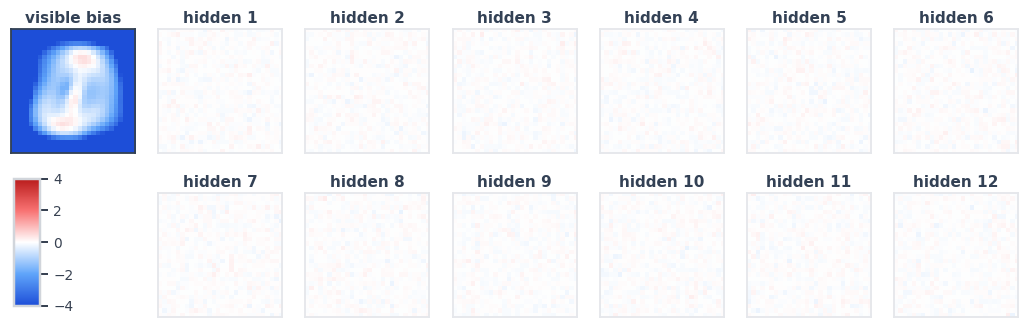

Starting the training
[13219  2716  4920  6568 13003 11410  8551 16753  2909 14542]
[ 3241 16746  7150  2492 15235 14273 13032  6380  5509    24]
[ 4257 18724 21368 17368  1893  3407 15099  8828  8780 20101]
[13840  4638 17623  9454 21297 19366 14342 13045 11790 12623]
epoch 1 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 2 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 3 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 4 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 5 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 6 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 7 / 150  Nt: 2  N: 10  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 8 / 150  Nt: 2  N: 11  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 9 / 150  Nt: 2  N: 11  L: 12  rate: 0.05  ga

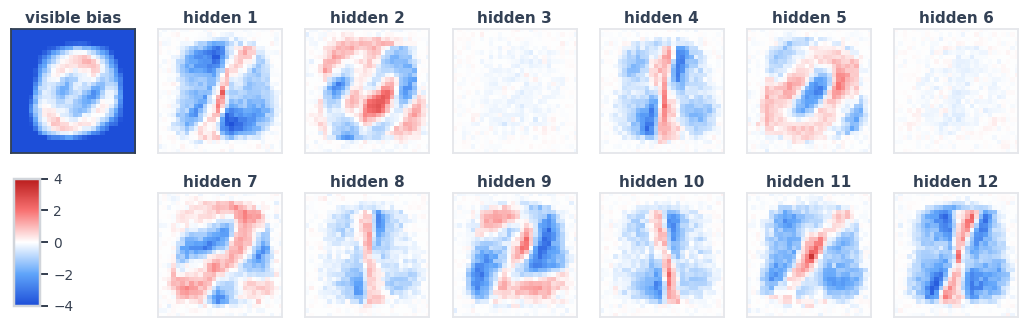

epoch 21 / 150  Nt: 2  N: 18  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 22 / 150  Nt: 2  N: 19  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 23 / 150  Nt: 2  N: 20  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 24 / 150  Nt: 2  N: 21  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 25 / 150  Nt: 2  N: 22  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 26 / 150  Nt: 2  N: 23  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 27 / 150  Nt: 2  N: 24  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 28 / 150  Nt: 2  N: 26  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 29 / 150  Nt: 2  N: 27  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 30 / 150  Nt: 2  N: 28  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 31 / 150  Nt: 2  N: 29  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 32 / 150  Nt: 2  N: 31  L: 12  rate: 0.05  gam: 

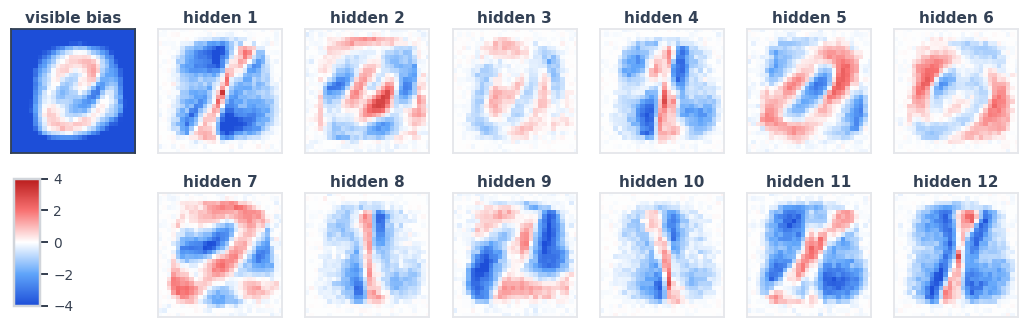

epoch 41 / 150  Nt: 2  N: 45  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 42 / 150  Nt: 2  N: 47  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 43 / 150  Nt: 2  N: 48  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 44 / 150  Nt: 2  N: 50  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 45 / 150  Nt: 2  N: 52  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 46 / 150  Nt: 2  N: 54  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 47 / 150  Nt: 2  N: 56  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 48 / 150  Nt: 2  N: 58  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 49 / 150  Nt: 2  N: 60  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 50 / 150  Nt: 2  N: 62  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 51 / 150  Nt: 2  N: 65  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 52 / 150  Nt: 2  N: 67  L: 12  rate: 0.05  gam: 

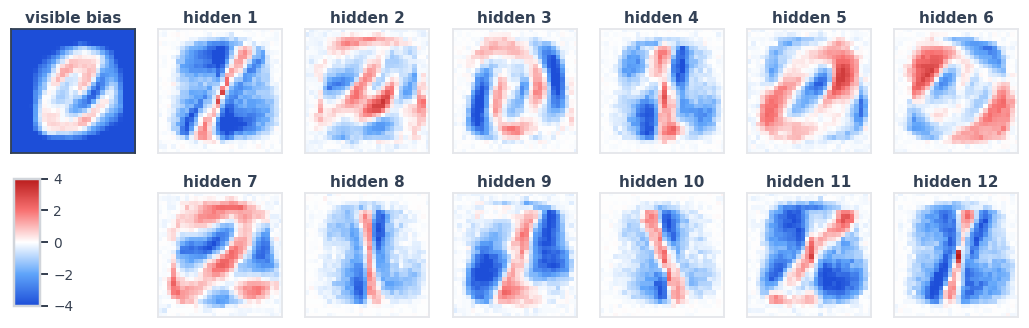

epoch 61 / 150  Nt: 2  N: 89  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 62 / 150  Nt: 2  N: 92  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 63 / 150  Nt: 2  N: 94  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 64 / 150  Nt: 2  N: 97  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 65 / 150  Nt: 2  N: 100  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 66 / 150  Nt: 2  N: 103  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 67 / 150  Nt: 2  N: 106  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 68 / 150  Nt: 2  N: 109  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 69 / 150  Nt: 2  N: 112  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 70 / 150  Nt: 2  N: 115  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 71 / 150  Nt: 2  N: 118  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 72 / 150  Nt: 2  N: 121  L: 12  rate: 0.0

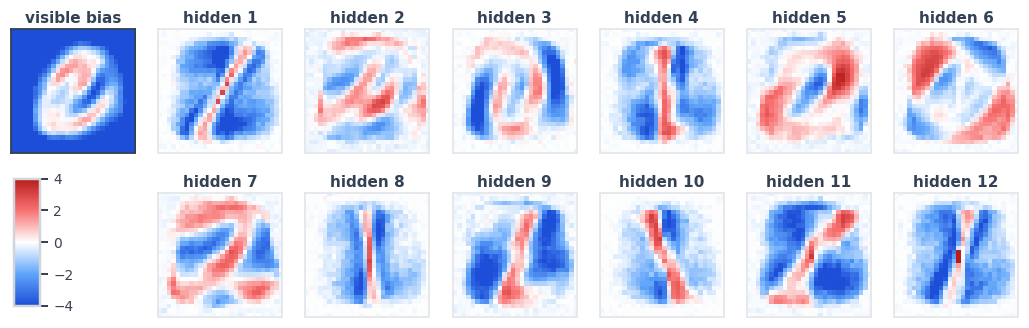

epoch 81 / 150  Nt: 2  N: 151  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 82 / 150  Nt: 2  N: 154  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 83 / 150  Nt: 2  N: 158  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 84 / 150  Nt: 2  N: 162  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 85 / 150  Nt: 2  N: 165  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 86 / 150  Nt: 2  N: 169  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 87 / 150  Nt: 2  N: 173  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 88 / 150  Nt: 2  N: 177  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 89 / 150  Nt: 2  N: 180  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 90 / 150  Nt: 2  N: 184  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 91 / 150  Nt: 2  N: 188  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 92 / 150  Nt: 2  N: 192  L: 12  rate:

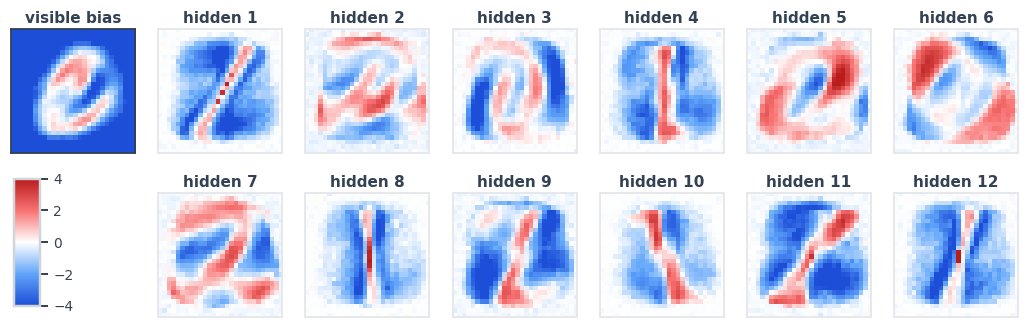

epoch 101 / 150  Nt: 2  N: 230  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 102 / 150  Nt: 2  N: 235  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 103 / 150  Nt: 2  N: 239  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 104 / 150  Nt: 2  N: 244  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 105 / 150  Nt: 2  N: 248  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 106 / 150  Nt: 2  N: 253  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 107 / 150  Nt: 2  N: 257  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 108 / 150  Nt: 2  N: 262  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 109 / 150  Nt: 2  N: 267  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 110 / 150  Nt: 2  N: 272  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 111 / 150  Nt: 2  N: 277  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 112 / 150  Nt: 2  N: 281  

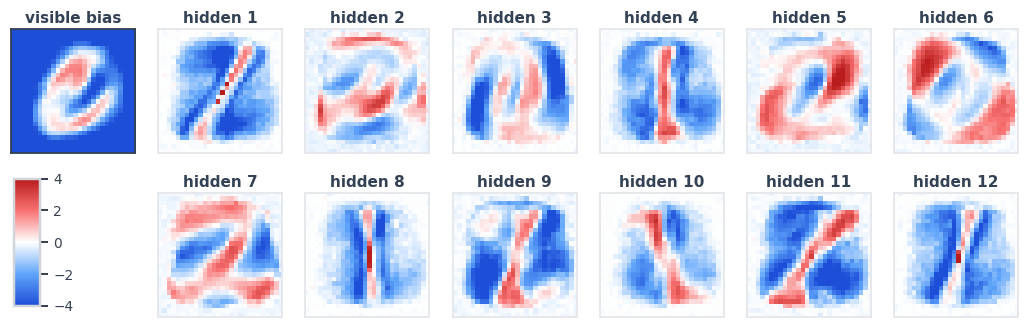

epoch 121 / 150  Nt: 2  N: 327  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 122 / 150  Nt: 2  N: 333  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 123 / 150  Nt: 2  N: 338  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 124 / 150  Nt: 2  N: 343  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 125 / 150  Nt: 2  N: 349  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 126 / 150  Nt: 2  N: 354  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 127 / 150  Nt: 2  N: 360  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 128 / 150  Nt: 2  N: 365  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 129 / 150  Nt: 2  N: 371  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 130 / 150  Nt: 2  N: 377  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 131 / 150  Nt: 2  N: 383  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 132 / 150  Nt: 2  N: 388  

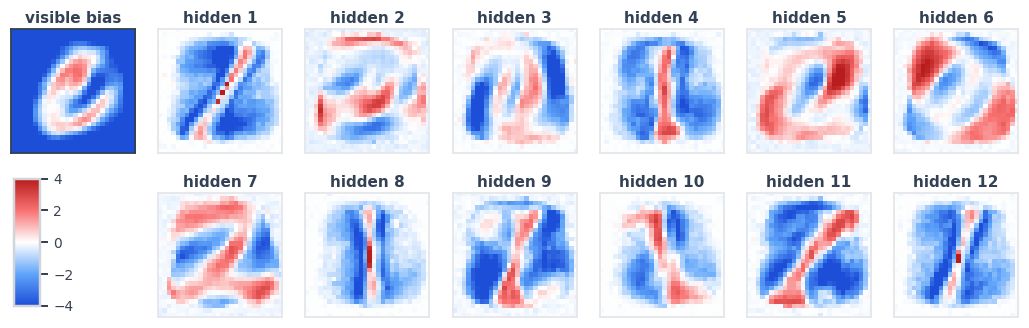

epoch 141 / 150  Nt: 2  N: 442  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 142 / 150  Nt: 2  N: 448  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 143 / 150  Nt: 2  N: 455  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 144 / 150  Nt: 2  N: 461  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 145 / 150  Nt: 2  N: 467  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 146 / 150  Nt: 2  N: 474  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 147 / 150  Nt: 2  N: 480  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 148 / 150  Nt: 2  N: 486  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 149 / 150  Nt: 2  N: 493  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False
epoch 150 / 150  Nt: 2  N: 500  L: 12  rate: 0.05  gam: 0.001 SPINS= False POTTS= False


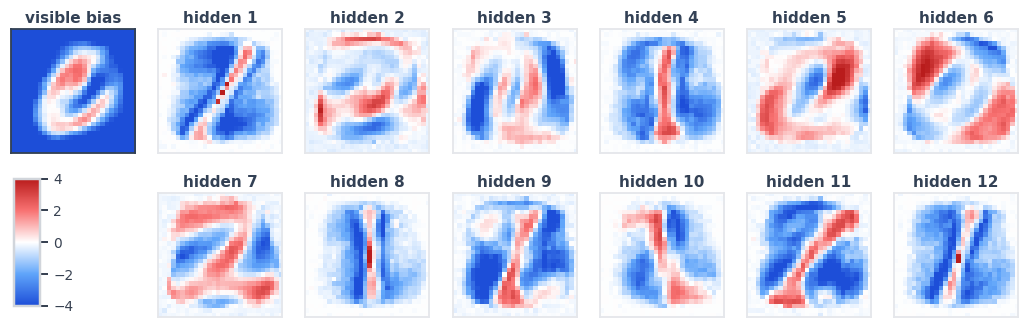

END of learning phase


In [13]:
# random seed for reproducibility
np.random.seed(12345)

# initial weights from a Normal distr. 
w = sigma * np.random.randn(D,L)
#a = sigma * np.random.randn(D)
# using Hinton initialization of visible biases
a = Hinton_bias_init(data)
# hidden biases initialized to zero
b = np.zeros(L)


# nr of epochs
Nepoch=150
# minibatches per epoch
Nmini=20
# minibatch size at initial epoch and final one
N_ini,N_fin=10,500
print(f"Nepoch={Nepoch}\nNmini={Nmini}")
# number of CD steps
Nt=2

# recording history of weights ("E" means epoch)
wE,aE,bE=np.zeros((Nepoch+1,D,L)),np.zeros((Nepoch+1,D)),np.zeros((Nepoch+1,L))
wE[0],aE[0],bE[0]=np.copy(w),np.copy(a),np.copy(b)
gwE,gw2E,gwE_d,gwE_m = np.zeros_like(wE),np.zeros_like(wE),np.zeros_like(wE),np.zeros_like(wE)
gaE,ga2E,gaE_d,gaE_m = np.zeros_like(aE),np.zeros_like(aE),np.zeros_like(aE),np.zeros_like(aE)
gbE,gb2E,gbE_d,gbE_m = np.zeros_like(bE),np.zeros_like(bE),np.zeros_like(bE),np.zeros_like(bE)
miniE = np.zeros(Nepoch+1)
pzE=np.zeros((Nepoch+1,Nz))
if GRAD=="RMSprop": 
    gw2,ga2,gb2 = np.zeros_like(w),np.zeros_like(a),np.zeros_like(b)

indices=np.arange(Nd).astype("int")
plot_weights_bias(wE, aE, 0, L, cols=L//2, save=False)

# for the plot with panels
Ncols=min(8,max(2,L//2))

if POTTS: print("Starting the training, POTTS=True")
else: print("Starting the training")


for epoch in range(1,1+Nepoch):
    # q maps epochs to interval [0,1]
    q = (epoch-1.)/(Nepoch-1.) 
    # N, size of the mini batch
    # stays closer to N_ini for some time, then it progressively accelerates toward N_fin
    N = int(N_ini + (N_fin-N_ini)*(q**2))
    #  l_rate interpolates between initial and final value
    l_rate = l_rate_ini + (l_rate_fin-l_rate_ini)*q

    for mini in range(Nmini):
        # initializitation for averages in minibatch
        # visible variables "v" --> "x"
        #  hidden variables "h" --> "z"
        x_data, x_model = np.zeros(D),np.zeros(D)
        z_data, z_model = np.zeros(L),np.zeros(L)
        xz_data,xz_model= np.zeros((D,L)),np.zeros((D,L))
        pz = np.zeros(L)
        
        # Minibatch of size N: points randomply picked (without repetition) from data
        selected = np.random.choice(indices,N,replace=False)
        if epoch==1 and mini<=3: print(selected)
        
        for k in range(N):
            
            x0 = data[selected[k]]
            # positive CD phase: generating z from x[k]
            z = CD_step(x0,w,b,POTTS=POTTS)
            x_data  += x0
            z_data  += z
            xz_data += np.outer(x0,z)
            # fantasy
            zf=np.copy(z)
            # Contrastive divergence with Nt steps
            for t in range(Nt):
                # negative CD pzase: generating fantasy xf from fantasy zf
                xf = CD_step(zf,w.T,a)
                # positive CD phase: generating fantasy zf from fantasy xf 
                zf = CD_step(xf,w,b,POTTS=POTTS)
            x_model += xf
            z_model += zf
            xz_model+= np.outer(xf,zf)
            # recording probability of encoding in z-space, if POTTS
            if POTTS: pz[zf]+=1
            
        
        # gradient of the likelihood: follow it along its positive direction
        gw_d,gw_m = xz_data/N, xz_model/N
        ga_d,ga_m = x_data/N, x_model/N
        gb_d,gb_m = z_data/N, z_model/N
        gw=np.copy(gw_d - gw_m)
        ga=np.copy(ga_d - ga_m)
        gb=np.copy(gb_d - gb_m)

        # gradient ascent step
        if GRAD=="RMSprop":
            # RMSprop gradient ascent
            gw2 = beta*gw2+(1-beta)*np.square(gw)
            ga2 = beta*ga2+(1-beta)*np.square(ga)
            gb2 = beta*gb2+(1-beta)*np.square(gb)
            w += l_rate*gw/sqrt(epsilon+gw2)
            a += l_rate*ga/sqrt(epsilon+ga2)
            b += l_rate*gb/sqrt(epsilon+gb2)
        else: 
            # defaulting to the vanilla stochastic gradient ascent (SGD)
            w += l_rate*gw
            a += l_rate*ga
            b += l_rate*gb
        # regularization (LASSO)
        if gamma>0.:
            w -= (gamma*l_rate)*sign(w)
            a -= (gamma*l_rate)*sign(a)
            b -= (gamma*l_rate)*sign(b)

    wE[epoch],gwE[epoch],gwE_d[epoch],gwE_m[epoch]=np.copy(w),np.copy(gw),np.copy(gw_d),np.copy(gw_m)
    aE[epoch],gaE[epoch],gaE_d[epoch],gaE_m[epoch]=np.copy(a),np.copy(ga),np.copy(ga_d),np.copy(ga_m)
    bE[epoch],gbE[epoch],gbE_d[epoch],gbE_m[epoch]=np.copy(b),np.copy(gb),np.copy(gb_d),np.copy(gb_m)
    miniE[epoch]=N
    if POTTS: pzE[epoch] = pz/np.sum(pz)
    print("epoch",epoch,"/",Nepoch," Nt:",Nt," N:",N," L:",L,
          " rate:",l_rate," gam:",gamma,"SPINS=",SPINS,"POTTS=",POTTS)

    if Nepoch<=100 or epoch%20==0 or epoch==Nepoch:
        plot_weights_bias(wE, aE, epoch, L, cols=Ncols, save=False)
            
    str_time_completion = datetime.datetime.now().strftime("_%Y%m%d_%H%M")

print("END of learning phase")

## Generative behaviour of the trained RBM

A trained RBM is a **generative model**: it defines $P(\mathbf{x})$ and can be
*sampled* to dream up new digits. Sampling is done by **block Gibbs sampling** —
the same alternating step used in CD, but now run freely with no data clamping:

$$\mathbf{x}_0 \;(\text{random data image})
\;\xrightarrow{\;P(\mathbf z\mid\mathbf x)\;} \mathbf{z}_t
\;\xrightarrow{\;P(\mathbf x\mid\mathbf z)\;} \mathbf{x}_{t+1}
\;\to\;\cdots$$

Each panel in the filmstrip below is one state of the chain; the tint marks
progress in time. A healthy RBM produces frames that **stay recognisable as
digits** and drift smoothly.

> **Temperature knob — `AF`.** Multiplying the weights and biases by an
> *amplification factor* $\text{AF}>1$ before the visible step sharpens every
> conditional, equivalent to **lowering the temperature** of the Boltzmann
> distribution. High AF → crisper but more frozen samples; $\text{AF}=1$ samples
> at the temperature the model was trained at.




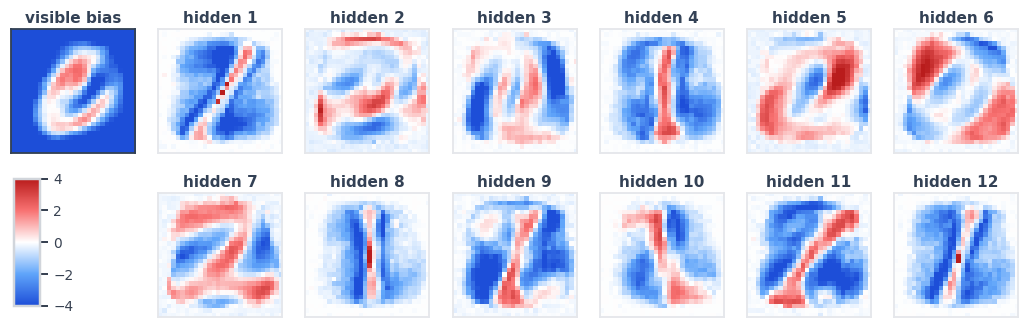

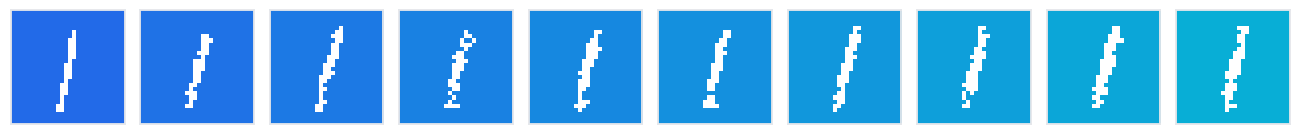

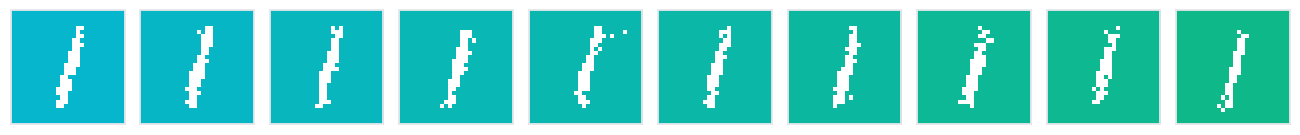

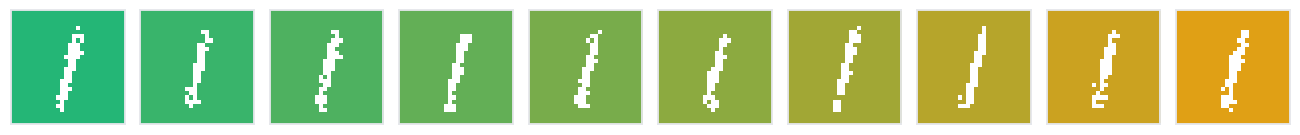

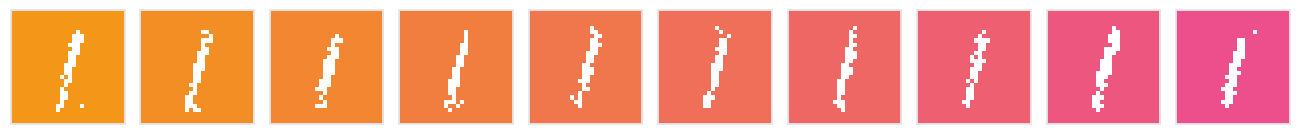

L: 12     amplification of weights: 1.0


In [14]:
ee=-1
NN=200
traj_x,traj_z = np.zeros((NN+2,D)), np.zeros((NN+2,L))
xf=np.copy(data[np.random.randint(Nd)])
traj_x[0]=np.copy(xf)

# AF: multiply weights and biases by a number >1 to achieve a more deterministic behavior,
# equivalent to lower the temperature in a Boltzmann weight -> select lowest energies

AF=1.

for t in range(NN):
    t1=t+1
    # positive CD phase: generating fantasy zf from fantasy xf 
    zf = CD_step(xf,1*wE[ee],1*bE[ee],POTTS=POTTS)
    traj_z[t] = np.copy(zf)
    # negative CD pzase: generating fantasy xf from fantasy zf
    xf = CD_step(zf,AF*wE[ee].T,AF*aE[ee])
    traj_x[t1] = np.copy(xf)


plot_weights_bias(wE, aE, Nepoch, L, cols=Ncols, save=False)

# vibrant filmstrip tints marking trajectory progress
_stops = [to_rgba(PALETTE[c]) for c in ("blue","teal","green","orange","pink")]
col0,col1,col2,col3,col4 = _stops
show_MNIST(traj_x[0:],Nex=10,colors=(col0,col1))
show_MNIST(traj_x[10:],Nex=10,colors=(col1,col2))
show_MNIST(traj_x[20:],Nex=10,colors=(col2,col3))
show_MNIST(traj_x[40:],Nex=10,colors=(col3,col4))
print("L:",L,"    amplification of weights:",AF)

## Energy Barriers and Quasi-Ergodicity of CD

### Why the CD chain gets trapped

Block Gibbs sampling alternates $\mathbf{z}_t\sim P(\mathbf z\mid\mathbf x_t)$ and
$\mathbf{x}_{t+1}\sim P(\mathbf x\mid\mathbf z_t)$, and its stationary
distribution *is* the RBM joint $P(\mathbf{x},\mathbf{z})$. In principle it
explores everything; in practice it is **quasi-ergodic** — if the model has carved
a deep low-energy basin for each digit class, the chain started on a "1" keeps
returning "1"s and essentially never visits "2".

The reason is an **energy barrier**: to travel from one basin to another the chain
must pass through intermediate images that are neither digit, and those have high
energy ⇒ vanishingly small probability ⇒ the chain almost never goes there.

### Free energy — the right quantity to track

The **free energy** of a visible configuration marginalises out the hidden layer:

$$F(\mathbf{x}) \;=\; -\,\mathbf{x}\!\cdot\!\mathbf{a}
\;-\;\sum_{j} \log\!\big(1 + e^{H_j}\big),
\qquad H_j = b_j + \textstyle\sum_i W_{ij}x_i$$

(for bits; $\operatorname{softplus}$ becomes $\log 2\cosh$ for spins, $\log\sum
e^{H_j}$ for POTTS). It satisfies $P(\mathbf{x})\propto e^{-F(\mathbf{x})}$, so
**low $F$ = high probability**, and crucially it is **exact and cheap** — no $z$
sampling needed.

> $F(\mathbf{x}) = \mathbb{E}_{\mathbf z}[E(\mathbf{x},\mathbf{z})] -
> \mathcal{H}[\mathbf z\mid\mathbf x]$ — free energy is the mean joint energy
> minus the conditional entropy. The joint energy $E(\mathbf{x},\mathbf{z})$ is
> thus a *stochastic upper bound* on $F$.

### The forced-transition diagnostic

We cannot wait for the chain to cross a barrier on its own — so we **force** it:

1. Pick $\mathbf{x}_{\text{start}}$ (digit A) and $\mathbf{x}_{\text{end}}$ (digit B) from the data.
2. Build an artificial path $\mathbf{x}_0,\dots,\mathbf{x}_T$ by flipping a growing
   fraction $t/T$ of the differing pixels — in a **randomised order** to avoid
   index artefacts.
3. Evaluate $F(\mathbf{x}_t)$ exactly along the path (and sample $E(\mathbf{x}_t,\mathbf{z})$ for comparison).

A **ridge** in $F$ in the middle of the path is the barrier — drawn explicitly,
this is the concrete explanation of the poor mixing.

### Making it quantitative

A single path proves nothing — fluctuations could fake a ridge. So we repeat over
**`n_pairs` independent image pairs $\times$ `n_repeats` random orderings**, and
report the mean with a 95 % confidence interval $\pm 1.96\,\sigma/\sqrt{n}$. The
barrier is then judged against the natural spread of energies *within* a class:

$$\text{SNR} \;=\; \frac{\Delta F_{\text{barrier}}}{\sigma_{\text{within}}},
\qquad
\Delta F_{\text{barrier}} = \max_t \overline{F}(\mathbf{x}_t)
- \tfrac12\big[F(\mathbf{x}_{\text{start}}) + F(\mathbf{x}_{\text{end}})\big].$$

$\text{SNR}\gg1$ means the barrier dwarfs ordinary within-class variation — it is
real, and the crossing probability is suppressed by $\sim e^{-\Delta F}$.

### CD mixing demonstration

Finally we let ordinary Gibbs chains run free for 300 steps from each digit class
and overlay their free-energy traces on the within-class bands. Chains that never
leave their starting band are quasi-ergodicity, caught in the act.


Digit 0: F mean=-37.0  std=29.8  n=150
Digit 1: F mean=-132.2  std=20.1  n=150
Digit 2: F mean=-9.6  std=29.9  n=150

Pooled within-class std  σ_within = 59.07


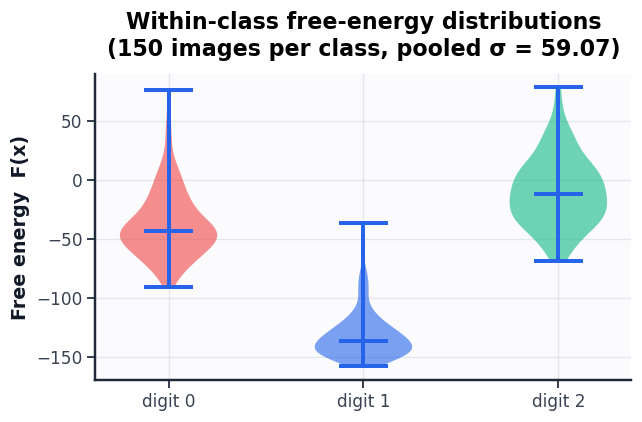

In [15]:

# Energy-barrier analysis — helper functions


def rbm_free_energy(x, w, a, b):
    
    H = np.clip(x @ w + b, -300, 300)
    return -(np.dot(x, a) + np.sum(np.log1p(np.exp(H))))


def rbm_energy(x, z, w, a, b):
    
    return -(np.dot(x, a) + np.dot(z, b) + float(x @ w @ z))


def sample_joint_energies(x, w, a, b, n_z=60):
    
    return np.array([rbm_energy(x, CD_step(x, w, b, POTTS=POTTS), w, a, b)
                     for _ in range(n_z)])


def forced_path(x_start, x_end, n_steps=50, seed=None):
    
    rng_loc = np.random.default_rng(seed)
    diff = np.where(x_start != x_end)[0].copy()
    rng_loc.shuffle(diff)
    path = np.empty((n_steps + 1, len(x_start)), dtype=int)
    path[0] = x_start
    for t in range(1, n_steps + 1):
        x = x_start.copy()
        x[diff[:int(len(diff) * t / n_steps)]] = x_end[diff[:int(len(diff) * t / n_steps)]]
        path[t] = x
    return path



# Section 1 — Within-class free-energy distributions

N_IMAGES_CLASS = 150   # images sampled per digit class

w_fin, a_fin, b_fin = wE[-1], aE[-1], bE[-1]

class_FE = {}   # free energies per digit
for d in range(Ndigit):
    idx = np.where(label == d)[0]
    chosen = rng.choice(idx, min(N_IMAGES_CLASS, len(idx)), replace=False)
    class_FE[d] = np.array([rbm_free_energy(data[i], w_fin, a_fin, b_fin)
                             for i in chosen])
    print(f"Digit {d}: F mean={class_FE[d].mean():.1f}  std={class_FE[d].std():.1f}"
          f"  n={len(class_FE[d])}")

# Pooled within-class std (for SNR denominator)
sigma_within = np.std(np.concatenate(list(class_FE.values())))
print(f"\nPooled within-class std  σ_within = {sigma_within:.2f}")

# Violin / box plot of within-class free-energy distributions
digit_colors = {0: PALETTE["red"], 1: PALETTE["blue"], 2: PALETTE["green"]}
fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot([class_FE[d] for d in range(Ndigit)],
                      positions=range(Ndigit), showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(digit_colors[i])
    pc.set_alpha(0.6)
ax.set_xticks(range(Ndigit))
ax.set_xticklabels([f"digit {d}" for d in range(Ndigit)])
ax.set_ylabel("Free energy  F(x)")
ax.set_title(f"Within-class free-energy distributions\n"
             f"({N_IMAGES_CLASS} images per class, pooled σ = {sigma_within:.2f})")
plt.tight_layout(); plt.show()


Pair 0→1: 32 profiles computed
Pair 0→2: 32 profiles computed
Pair 1→2: 32 profiles computed


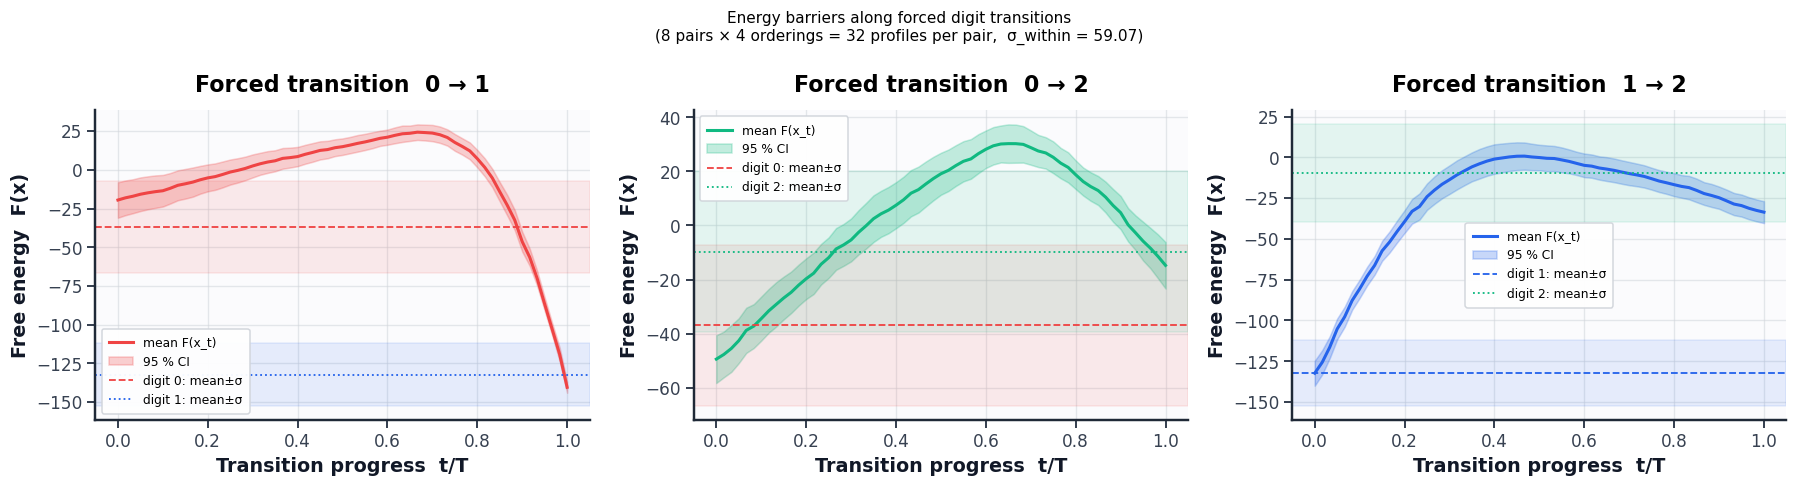

In [16]:
# Section 2 — Energy barrier along forced transitions (all digit pairs)

N_PAIRS   = 8    # independent (x_start, x_end) pairs per digit pair
N_REPEATS = 4    # random pixel-flip orderings per image pair
N_STEPS   = 60   # steps along each transition path
N_Z       = 60   # hidden samples per step for joint-energy estimate

digit_pairs = [(d1, d2) for d1 in range(Ndigit) for d2 in range(d1+1, Ndigit)]

barrier_results = {}   # keyed by (d1, d2)

for (d1, d2) in digit_pairs:
    idx1 = np.where(label == d1)[0]
    idx2 = np.where(label == d2)[0]
    FE_profiles  = []   # shape (N_PAIRS*N_REPEATS, N_STEPS+1)
    JE_profiles  = []

    for pair in range(N_PAIRS):
        x_s = data[rng.choice(idx1)]
        x_e = data[rng.choice(idx2)]
        for rep in range(N_REPEATS):
            path = forced_path(x_s, x_e, n_steps=N_STEPS, seed=pair*100+rep)
            FE_profiles.append([rbm_free_energy(x, w_fin, a_fin, b_fin) for x in path])
            JE_profiles.append([sample_joint_energies(x, w_fin, a_fin, b_fin, N_Z).mean()
                                 for x in path])

    barrier_results[(d1, d2)] = dict(
        FE=np.array(FE_profiles),   # (n_trials, N_STEPS+1)
        JE=np.array(JE_profiles),
    )
    n_trials = len(FE_profiles)
    print(f"Pair {d1}→{d2}: {n_trials} profiles computed")

# Plot: free energy profiles with 95 % CI for each digit pair 
pair_colors = {(0,1): PALETTE["red"], (0,2): PALETTE["green"], (1,2): PALETTE["blue"]}
t_arr = np.linspace(0, 1, N_STEPS + 1)

fig, axes = plt.subplots(1, len(digit_pairs), figsize=(5.5*len(digit_pairs), 4.5),
                         sharey=False)
if len(digit_pairs) == 1: axes = [axes]

for ax, (d1, d2) in zip(axes, digit_pairs):
    FE = barrier_results[(d1, d2)]['FE']   # (n_trials, N_STEPS+1)
    n  = FE.shape[0]
    mu = FE.mean(axis=0)
    ci = 1.96 * FE.std(axis=0) / np.sqrt(n)   # 95 % CI half-width

    color = pair_colors[(d1, d2)]
    ax.plot(t_arr, mu, "-", color=color, lw=2, label="mean F(x_t)")
    ax.fill_between(t_arr, mu - ci, mu + ci, color=color, alpha=0.25,
                    label="95 % CI")

    # Horizontal bands for within-class distributions
    for d, ls in [(d1, "--"), (d2, ":")]:
        m, s = class_FE[d].mean(), class_FE[d].std()
        ax.axhspan(m - s, m + s, alpha=0.10, color=digit_colors[d])
        ax.axhline(m, color=digit_colors[d], lw=1.2, ls=ls,
                   label=f"digit {d}: mean±σ")

    ax.set_xlabel("Transition progress  t/T")
    ax.set_ylabel("Free energy  F(x)")
    ax.set_title(f"Forced transition  {d1} → {d2}")
    ax.legend(fontsize=8)

plt.suptitle(f"Energy barriers along forced digit transitions\n"
             f"({N_PAIRS} pairs × {N_REPEATS} orderings = {N_PAIRS*N_REPEATS} profiles per pair,"
             f"  σ_within = {sigma_within:.2f})",
             fontsize=10)
plt.tight_layout(); plt.show()


In [17]:
# Section 3 — Quantitative barrier summary (SNR table)

# For each digit pair we compute:
#   ΔF_barrier = max(μ_path) − ½[μ(start) + μ(end)]
#              = height of the free-energy ridge above the average endpoint
#   SNR        = ΔF_barrier / σ_within
#
# A large SNR (>> 1) means the barrier is real and not a sampling fluctuation.

print(f"{'Pair':>8}  {'ΔF barrier':>12}  {'SNR':>8}  {'max F':>10}  {'F(start)':>10}  {'F(end)':>10}")
print("-" * 70)
for (d1, d2) in digit_pairs:
    FE = barrier_results[(d1, d2)]['FE']
    mu = FE.mean(axis=0)
    ci = 1.96 * FE.std(axis=0) / np.sqrt(FE.shape[0])

    F_start = mu[0];   F_end = mu[-1]
    F_max   = mu.max()
    dF      = F_max - 0.5*(F_start + F_end)
    snr     = dF / sigma_within
    ci_max  = ci[mu.argmax()]

    print(f"  {d1}→{d2}    {dF:+10.2f}    {snr:>6.2f}   "
          f"{F_max:10.2f}  {F_start:10.2f}  {F_end:10.2f}")
    print(f"{'':>8}  95% CI at peak: ±{ci_max:.2f}")

print()
print("σ_within (pooled within-class std) =", round(sigma_within, 2))
print()
print("Interpretation:")
print("  SNR >> 1  →  barrier is many within-class fluctuations high")
print("  SNR >> 1  →  a spontaneous CD transition is exponentially suppressed")
print("  A Boltzmann factor exp(-ΔF) gives the relative probability of crossing.")
for (d1, d2) in digit_pairs:
    FE  = barrier_results[(d1, d2)]['FE']
    dF  = FE.mean(axis=0).max() - 0.5*(FE.mean(axis=0)[0] + FE.mean(axis=0)[-1])
    print(f"  Pair {d1}→{d2}: crossing probability suppressed by ≈ exp(-{dF:.1f}) = {np.exp(-dF):.2e}")


    Pair    ΔF barrier       SNR       max F    F(start)      F(end)
----------------------------------------------------------------------
  0→1       +104.26      1.77        24.32      -19.48     -140.39
          95% CI at peak: ±5.02
  0→2        +62.38      1.06        30.28      -49.44      -14.76
          95% CI at peak: ±7.11
  1→2        +83.77      1.42         0.81     -132.34      -33.57
          95% CI at peak: ±8.36

σ_within (pooled within-class std) = 59.07

Interpretation:
  SNR >> 1  →  barrier is many within-class fluctuations high
  SNR >> 1  →  a spontaneous CD transition is exponentially suppressed
  A Boltzmann factor exp(-ΔF) gives the relative probability of crossing.
  Pair 0→1: crossing probability suppressed by ≈ exp(-104.3) = 5.26e-46
  Pair 0→2: crossing probability suppressed by ≈ exp(-62.4) = 8.12e-28
  Pair 1→2: crossing probability suppressed by ≈ exp(-83.8) = 4.17e-37


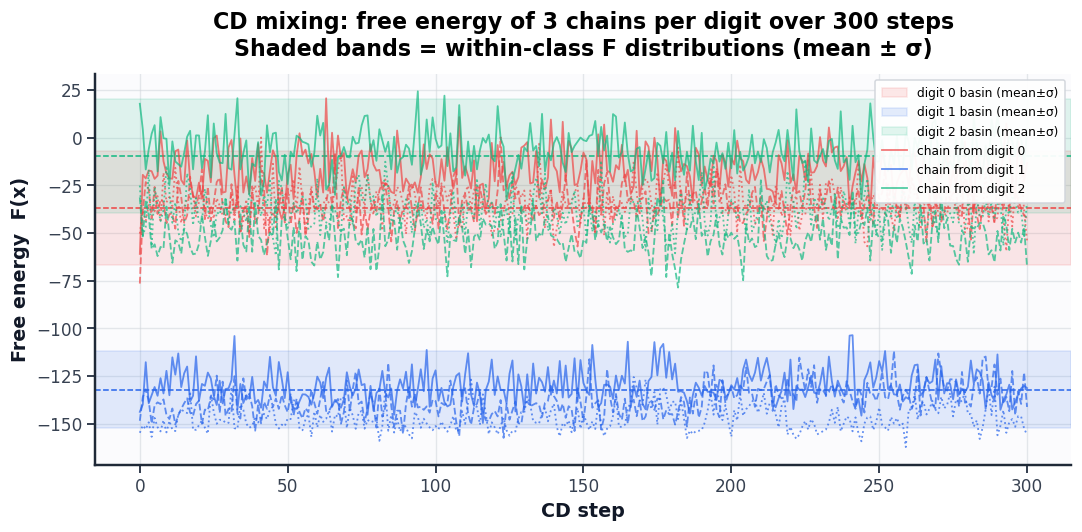

Fraction of CD steps that crossed into a different basin:
  Starting digit 0: 0.0% of steps outside starting basin  (0/900 steps, 3 chains)
  Starting digit 1: 0.6% of steps outside starting basin  (5/900 steps, 3 chains)
  Starting digit 2: 0.0% of steps outside starting basin  (0/900 steps, 3 chains)


In [18]:
# Section 4 — CD mixing demonstration
# Run a Gibbs/CD chain for N_CD_STEPS steps from a starting image of each digit.
# Track the free energy at each step and overlay on the within-class bands.
# If CD mixes well, chains should cross basins; if not, they stay confined.

N_CD_STEPS = 300
n_chains    = 3    # independent chains per starting digit

fig, ax = plt.subplots(figsize=(10, 5))

# Within-class free-energy bands (shaded)
for d in range(Ndigit):
    m, s = class_FE[d].mean(), class_FE[d].std()
    ax.axhspan(m - s, m + s, alpha=0.12, color=digit_colors[d],
               label=f"digit {d} basin (mean±σ)")
    ax.axhline(m, color=digit_colors[d], lw=1.0, ls="--")

# CD chains
steps_arr = np.arange(N_CD_STEPS + 1)
line_styles = ["-", "--", ":"]

for d_start in range(Ndigit):
    idx_d = np.where(label == d_start)[0]
    for chain_idx in range(n_chains):
        x_chain = data[rng.choice(idx_d)].copy()
        FE_chain = np.empty(N_CD_STEPS + 1)
        FE_chain[0] = rbm_free_energy(x_chain, w_fin, a_fin, b_fin)

        for t in range(1, N_CD_STEPS + 1):
            z_chain = CD_step(x_chain, w_fin, b_fin, POTTS=POTTS)
            x_chain = CD_step(z_chain, w_fin.T, a_fin)
            FE_chain[t] = rbm_free_energy(x_chain, w_fin, a_fin, b_fin)

        ax.plot(steps_arr, FE_chain,
                color=digit_colors[d_start], alpha=0.7,
                lw=1.2, ls=line_styles[chain_idx],
                label=f"chain from digit {d_start}" if chain_idx == 0 else "")

ax.set_xlabel("CD step")
ax.set_ylabel("Free energy  F(x)")
ax.set_title(f"CD mixing: free energy of {n_chains} chains per digit over {N_CD_STEPS} steps\n"
             "Shaded bands = within-class F distributions (mean ± σ)")
# deduplicate legend
handles, labels_leg = ax.get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

#  Quantitative mixing score 
print("Fraction of CD steps that crossed into a different basin:")
for d_start in range(Ndigit):
    basin_mean  = class_FE[d_start].mean()
    basin_sigma = class_FE[d_start].std()
    idx_d       = np.where(label == d_start)[0]
    n_cross_total, n_total = 0, 0

    for chain_idx in range(n_chains):
        x_chain = data[rng.choice(idx_d)].copy()
        for t in range(N_CD_STEPS):
            z_chain = CD_step(x_chain, w_fin, b_fin, POTTS=POTTS)
            x_chain = CD_step(z_chain, w_fin.T, a_fin)
            F_now   = rbm_free_energy(x_chain, w_fin, a_fin, b_fin)
            # crossed if free energy left the starting basin by more than 2σ
            if abs(F_now - basin_mean) > 2 * sigma_within:
                n_cross_total += 1
            n_total += 1

    frac = n_cross_total / n_total
    print(f"  Starting digit {d_start}: {frac*100:.1f}% of steps outside starting basin"
          f"  ({n_cross_total}/{n_total} steps, {n_chains} chains)")


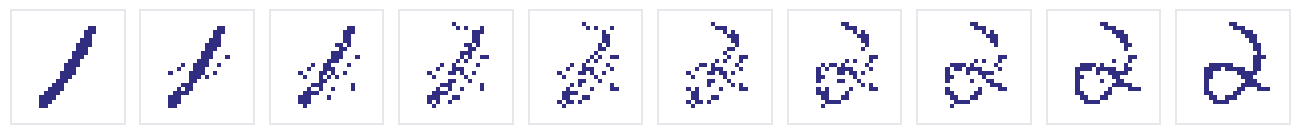

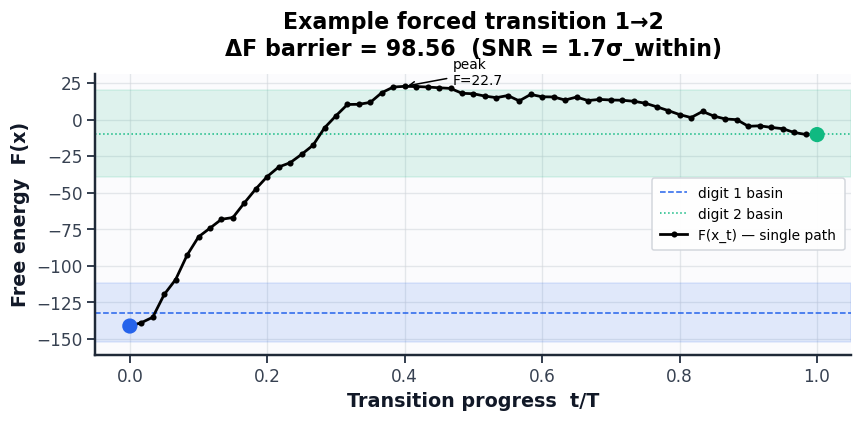

Pixels differing between the two images: 117/784
Barrier peak at step 24/60  (t/T = 0.40)


In [19]:
# Section 5 — Visualise one forced path and its free energy simultaneously

d1_ex, d2_ex = 1, 2

idx1_ex = rng.choice(np.where(label == d1_ex)[0])
idx2_ex = rng.choice(np.where(label == d2_ex)[0])
path_ex = forced_path(data[idx1_ex], data[idx2_ex], n_steps=N_STEPS, seed=77)
FE_ex   = np.array([rbm_free_energy(x, w_fin, a_fin, b_fin) for x in path_ex])

# Show 10 frames spaced along the path
frame_idx = np.linspace(0, N_STEPS, 10, dtype=int)
show_MNIST(path_ex[frame_idx], Nex=10)

# Overlay free energy and within-class bands
fig, ax = plt.subplots(figsize=(8, 4))
for d, ls in [(d1_ex, "--"), (d2_ex, ":")]:
    m, s = class_FE[d].mean(), class_FE[d].std()
    ax.axhspan(m-s, m+s, alpha=0.12, color=digit_colors[d])
    ax.axhline(m, color=digit_colors[d], lw=1, ls=ls, label=f"digit {d} basin")

ax.plot(t_arr, FE_ex, "ko-", ms=4, lw=1.8, label="F(x_t) — single path")
ax.scatter([0, 1], [FE_ex[0], FE_ex[-1]], s=80, zorder=5,
           color=[digit_colors[d1_ex], digit_colors[d2_ex]])

# Mark barrier peak
peak = FE_ex.argmax()
ax.annotate(f"peak\nF={FE_ex[peak]:.1f}",
            xy=(t_arr[peak], FE_ex[peak]),
            xytext=(t_arr[peak]+0.07, FE_ex[peak]+1),
            arrowprops=dict(arrowstyle="->"), fontsize=9)

dF_ex = FE_ex[peak] - 0.5*(FE_ex[0]+FE_ex[-1])
ax.set_xlabel("Transition progress  t/T")
ax.set_ylabel("Free energy  F(x)")
ax.set_title(f"Example forced transition {d1_ex}→{d2_ex}\n"
             f"ΔF barrier = {dF_ex:.2f}  (SNR = {dF_ex/sigma_within:.1f}σ_within)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Pixels differing between the two images: {int((data[idx1_ex]!=data[idx2_ex]).sum())}/{D}")
print(f"Barrier peak at step {peak}/{N_STEPS}  (t/T = {t_arr[peak]:.2f})")


## Gradient RMS monitoring

The **root-mean-square of the gradient** — measured here as the standard
deviation of $g_W,\,g_a,\,g_b$ at each epoch — is the single most informative
training diagnostic for an RBM.

| Regime | What the RMS curve does | Interpretation |
|--------|-------------------------|----------------|
| **Early** | large, slowly decaying | model far from data, learning fast |
| **Descent** | steady power-law decay | productive learning |
| **Floor** | flattens out | gradient signal $\approx$ sampling noise |

The dashed reference line $\sim 1/\sqrt{N}$ is the **statistical noise floor**: with
a minibatch of size $N$ the CD gradient has irreducible Monte-Carlo noise of that
order. Once the measured RMS reaches this line, further epochs mostly chase noise —
the right response is to **enlarge the minibatch or lower the learning rate**,
which is exactly what the minibatch schedule does.

> Plotting on **log–log axes** turns power-law decay into a straight line, making
> it easy to read off the convergence exponent and spot the transition to the
> noise floor.


NE= 150


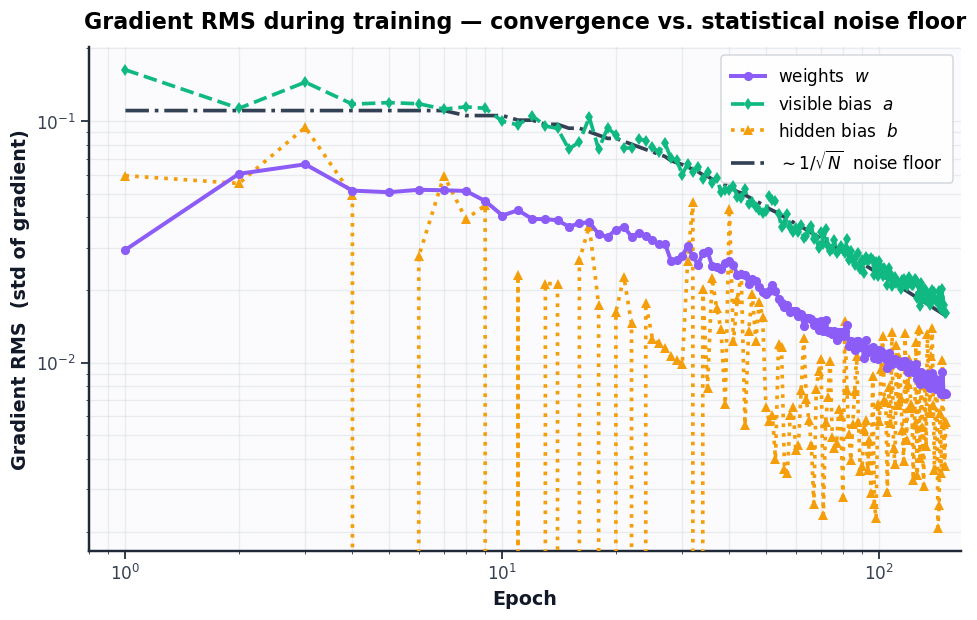

saved: FIG/RBM_grad_MNIST3_E150_N10-500_RMSprop-0.05-0.05_CD-2_L12_reg0.001.png


In [20]:
def make_fname(strin):
    fname="FIG/RBM_"+strin+"_MNIST"+str(Ndigit)+"_E"+str(NE)+"_N"+str(N_ini)+"-"+str(N_fin)
    fname=fname+"_"+GRAD+"-"+str(l_rate_ini)+"-"+str(l_rate_fin)+"_CD-"+str(Nt)+"_L"+str(L)
    if gamma>0:  fname=fname+"_reg"+str(gamma)
    return fname+".png"

NE = len(gwE)-1
print("NE=", NE)
mgw, mga, mgb, epo = np.zeros(NE), np.zeros(NE), np.zeros(NE), np.zeros(NE)
# compute RMS (std) of each gradient during epochs
for ep in range(1, 1+NE):
    epo[ep-1]   = ep
    mgw[ep-1]   = np.std(gwE[ep])
    mga[ep-1]   = np.std(gaE[ep])
    mgb[ep-1]   = np.std(gbE[ep])

#  plot 
fig, ax = plt.subplots(1, 1, figsize=(9, 5.8))
fig.patch.set_facecolor("white")

ax.plot(epo, mgw, "o-",  c=PALETTE["purple"], ms=6, lw=2.6,
        label=r"weights  $w$",        zorder=10)
ax.plot(epo, mga, "d--", c=PALETTE["green"],  ms=6, lw=2.4,
        label=r"visible bias  $a$",   zorder=6)
ax.plot(epo, mgb, "^:",  c=PALETTE["orange"], ms=7, lw=2.4,
        label=r"hidden bias  $b$",    zorder=8)
ax.plot(epo, .35/sqrt(miniE[1:]), "-.", c=PALETTE["slate"], lw=2.4,
        label=r"$\sim 1/\sqrt{N}$  noise floor", zorder=4)

ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient RMS  (std of gradient)")
ax.set_title("Gradient RMS during training — convergence vs. statistical noise floor")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.8, Nepoch*1.1)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, which="both", alpha=0.4)

fname = make_fname("grad")
fig.savefig(fname, dpi=200, bbox_inches="tight", pad_inches=0.05)
plt.tight_layout(); plt.show()
print("saved:", fname)

## Save weights over epochs to file

The full parameter trajectory (`wE`, `aE`, `bE` — one snapshot per epoch) is
written to `.npy` files in `WEIGHTS/`. The filename encodes every hyperparameter
of the run (digits, $L$, optimiser, learning rate, epochs, regularisation,
encoding) plus a timestamp, so experiments are **self-documenting** and can be
reloaded later for comparison without re-training.


In [21]:
def make_weights_fname(label,dname="WEIGHTS"):
    fname=dname+"/"+label+"_"+str_simul+"_MNIST"+str(Ndigit)+"_L"+str(L)
    fname=fname+"_"+GRAD+"-"+"{:.2f}".format(l_rate_ini)+"-"+"{:.2f}".format(l_rate_fin)+"_Ep"+str(Nepoch)
    if gamma>0:  fname=fname+"_reg"+"{:.3g}".format(gamma)
    if POTTS: fname+="_POTTS"
    if SPINS: fname+="_SPINS"
    fname=fname+str_time_completion
    return fname+".npy"

def save_epochs(qE,label):
    fname=make_weights_fname(label)
    print(fname)
    np.save(fname,qE)

save_epochs(wE,"w")
save_epochs(bE,"b")
save_epochs(aE,"a")

WEIGHTS/w_RBM_MNIST3_L12_RMSprop-0.05-0.05_Ep150_reg0.001_20260515_0150.npy
WEIGHTS/b_RBM_MNIST3_L12_RMSprop-0.05-0.05_Ep150_reg0.001_20260515_0150.npy
WEIGHTS/a_RBM_MNIST3_L12_RMSprop-0.05-0.05_Ep150_reg0.001_20260515_0150.npy


## Hyperparameter Study

  Here we ask the comparative question: **which
hyperparameters actually matter?** Ten configurations are trained — each changing
exactly one knob away from the baseline — and scored on four complementary
diagnostics.

### The four diagnostics

| # | Metric | Measures | Better when |
|---|--------|----------|-------------|
| 1 | Final gradient RMS, $\mathrm{std}(g_W)$ | convergence | **low** — settled near an optimum |
| 2 | Filter sharpness, $\mathrm{std}(W)$ | feature quality | **high** — distinct, structured receptive fields |
| 3 | Generative Gibbs samples | realism | visually **recognisable** digits |
| 4 | Energy barrier $\Delta F$ (1→2) | basin structure | **high** — model carved clear per-class basins |

### The ten configurations

Each row changes **one** factor; everything else equals the baseline (RMSprop,
bits, $L=12$, $N_t=2$, $\gamma=10^{-3}$), trained 50 epochs.

| Key | Knob varied | Hypothesis being tested |
|-----|-------------|-------------------------|
| `baseline` | — (epoch-50 snapshot of the full run) | reference point |
| `SGD` | optimiser → plain SGD, $\eta=0.5$ | does RMSprop's adaptivity matter? |
| `SPINS` | encoding → $\{-1,+1\}$ | does the energy gap of 2 help or hurt? |
| `POTTS` | hidden layer → one-hot ($L$ states) | does mutual inhibition aid clustering? |
| `no_reg` | $\gamma = 0$ | what does L1 regularisation buy us? |
| `strong_reg` | $\gamma = 10^{-2}$ | can over-shrinkage erase the features? |
| `L6` | capacity → 6 hidden units | is the model under-parameterised? |
| `L24` | capacity → 24 hidden units | does extra capacity pay off? |
| `Nt1` | CD-1 | how biased is the cheapest gradient? |
| `Nt5` | CD-5 | does a better negative phase sharpen learning? |

> A fully **vectorised** trainer (`train_rbm_cfg`) replaces the per-sample Python
> loop with batched matrix ops, so all ten 50-epoch runs finish quickly.


In [22]:
# Generic helpers for the hyperparameter study

def _sig(x):

    return 1. / (1. + np.exp(-np.clip(x, -300, 300)))


def _potts_sample(H):
    
    Hs = H - H.max(axis=1, keepdims=True)          # numerical stability
    p  = np.exp(Hs); p /= p.sum(axis=1, keepdims=True)
    F  = np.cumsum(p, axis=1)
    r  = np.random.rand(H.shape[0], 1)
    chosen = (F > r).argmax(axis=1)                 # first index where CDF > r
    z = np.zeros(H.shape, dtype=int)
    z[np.arange(H.shape[0]), chosen] = 1
    return z


def fe_cfg(x, w, a, b, SPINS=False, POTTS=False):
    """
    Exact free energy F(x) = -(x·a + log Z_h(x)).

    log Z_h(x) sums/integrates over all hidden configurations:
      - bits  : Σ_j log(1 + exp(H_j))          [softplus]
      - spins : Σ_j log(exp(H_j) + exp(−H_j))  [log(2 cosh)]
      - POTTS : log Σ_j exp(H_j)                [log-sum-exp]
    where H_j = b_j + (W^T x)_j.
    """
    H = np.clip(x @ w + b, -300, 300)
    if POTTS:
        # single partition function over one-hot states
        lZ = float(np.log(np.sum(np.exp(H - H.max()))) + H.max())
    elif SPINS:
        lZ = float(np.sum(np.log(np.exp(H) + np.exp(-H))))
    else:
        lZ = float(np.sum(np.log1p(np.exp(H))))
    return -(float(x @ a) + lZ)


def train_rbm_cfg(data_01, L=12, Nt=2, gamma=0.001,
                  GRAD="RMSprop", SPINS=False, POTTS=False,
                  Nepoch=50, Nmini=20, N_batch=200,
                  l_rate=0.05, beta=0.9, eps=1e-4, seed=42, verbose=True):
   
    x_min_c = -1 if SPINS else 0
    gap_c   = 2. if SPINS else 1.
    data_c  = (np.where(data_01 > 0, 1, -1) if SPINS else data_01).astype(float)
    Nd_c, D_c = data_c.shape

    np.random.seed(seed)
    w = np.sqrt(4. / (L + D_c)) * np.random.randn(D_c, L)
    xm = np.clip(data_c.mean(0), x_min_c + 1e-4, 1. - 1e-4)
    a  = (1./gap_c) * (np.log(xm - x_min_c) - np.log(1. - xm))
    b  = np.zeros(L)

    gw2, ga2, gb2 = np.zeros_like(w), np.zeros_like(a), np.zeros_like(b)
    idx = np.arange(Nd_c)
    rms_hist = []
    gw = np.zeros_like(w)

    for ep in range(Nepoch):
        for mi in range(Nmini):
            x0 = data_c[np.random.choice(idx, N_batch, replace=False)]

            #  positive phase 
            H0 = x0 @ w + b                                   # (N, L)
            if POTTS:
                z0 = _potts_sample(H0)
            else:
                z0 = np.where(np.random.rand(*H0.shape) < _sig(gap_c * H0), 1, x_min_c)

            # negative phase (Nt CD steps) 
            xf, zf = x0.copy(), z0.copy()
            for _ in range(Nt):
                Hv = zf @ w.T + a                             # (N, D)
                xf = np.where(np.random.rand(*Hv.shape) < _sig(gap_c * Hv), 1, x_min_c)
                Hh = xf @ w + b                               # (N, L)
                if POTTS:
                    zf = _potts_sample(Hh)
                else:
                    zf = np.where(np.random.rand(*Hh.shape) < _sig(gap_c * Hh), 1, x_min_c)

            # gradients 
            gw = (x0.T @ z0 - xf.T @ zf) / N_batch
            ga = (x0 - xf).mean(0)
            gb = (z0 - zf).mean(0)

            # update 
            if GRAD == "RMSprop":
                gw2 = beta*gw2 + (1-beta)*gw**2
                ga2 = beta*ga2 + (1-beta)*ga**2
                gb2 = beta*gb2 + (1-beta)*gb**2
                w += l_rate * gw / np.sqrt(eps + gw2)
                a += l_rate * ga / np.sqrt(eps + ga2)
                b += l_rate * gb / np.sqrt(eps + gb2)
            else:
                w += l_rate * gw
                a += l_rate * ga
                b += l_rate * gb

            if gamma > 0:
                w -= gamma * l_rate * np.sign(w)
                a -= gamma * l_rate * np.sign(a)
                b -= gamma * l_rate * np.sign(b)

        rms_hist.append(np.std(gw))

    if verbose:
        print(f"  done — final grad_rms = {rms_hist[-1]:.5f}")
    return dict(w=w, a=a, b=b, rms=np.array(rms_hist),
                x_min=x_min_c, gap=gap_c,
                SPINS=SPINS, POTTS=POTTS, L=L, Nt=Nt, gamma=gamma, GRAD=GRAD)


print("Generic functions defined: _sig, _potts_sample, fe_cfg, train_rbm_cfg")


Generic functions defined: _sig, _potts_sample, fe_cfg, train_rbm_cfg


In [23]:

# Define configurations and train each one (50 epochs, vectorised)

NEPOCH_HP = 50
N_BATCH_HP = 200

configs = {
    "SGD"        : dict(GRAD="SGD",      SPINS=False, POTTS=False, L=12, Nt=2,  gamma=0.001, l_rate=0.50),
    "SPINS"      : dict(GRAD="RMSprop",  SPINS=True,  POTTS=False, L=12, Nt=2,  gamma=0.001, l_rate=0.05),
    "POTTS"      : dict(GRAD="RMSprop",  SPINS=False, POTTS=True,  L=12, Nt=2,  gamma=0.001, l_rate=0.05),
    "no_reg"     : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=12, Nt=2,  gamma=0.0,   l_rate=0.05),
    "strong_reg" : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=12, Nt=2,  gamma=0.01,  l_rate=0.05),
    "L6"         : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=6,  Nt=2,  gamma=0.001, l_rate=0.05),
    "L24"        : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=24, Nt=2,  gamma=0.001, l_rate=0.05),
    "Nt1"        : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=12, Nt=1,  gamma=0.001, l_rate=0.05),
    "Nt5"        : dict(GRAD="RMSprop",  SPINS=False, POTTS=False, L=12, Nt=5,  gamma=0.001, l_rate=0.05),
}
 
hp_results = {}

# Baseline: use epoch-50 snapshot of the already-trained model
ep50 = min(50, len(wE)-1)
hp_results["baseline"] = dict(
    w=wE[ep50].copy(), a=aE[ep50].copy(), b=bE[ep50].copy(),
    rms=np.array([np.std(gwE[e]) for e in range(1, ep50+1)]),
    x_min=0, gap=1., SPINS=False, POTTS=False, L=L, Nt=Nt,
    gamma=gamma, GRAD=GRAD,
)
print(f"baseline (epoch-{ep50} snapshot): grad_rms = {hp_results['baseline']['rms'][-1]:.5f}")

# Train all other configurations 
for name, cfg in configs.items():
    print(f"\nTraining [{name}] ...")
    hp_results[name] = train_rbm_cfg(
        data, Nepoch=NEPOCH_HP, Nmini=20, N_batch=N_BATCH_HP, seed=42, **cfg
    )

cfg_order = ["baseline", "SGD", "SPINS", "POTTS",
             "no_reg", "strong_reg", "L6", "L24", "Nt1", "Nt5"]
cfg_colors = {
    "baseline":   PALETTE["slate"],
    "SGD":        PALETTE["red"],
    "SPINS":      PALETTE["orange"],
    "POTTS":      PALETTE["pink"],
    "no_reg":     PALETTE["lime"],
    "strong_reg": PALETTE["green"],
    "L6":         PALETTE["teal"],
    "L24":        PALETTE["blue"],
    "Nt1":        PALETTE["rose"],
    "Nt5":        PALETTE["indigo"],
}

print("\nAll configurations trained.")


baseline (epoch-50 snapshot): grad_rms = 0.01917

Training [SGD] ...
  done — final grad_rms = 0.01630

Training [SPINS] ...
  done — final grad_rms = 0.17710

Training [POTTS] ...
  done — final grad_rms = 0.00784

Training [no_reg] ...
  done — final grad_rms = 0.01340

Training [strong_reg] ...
  done — final grad_rms = 0.01394

Training [L6] ...
  done — final grad_rms = 0.01547

Training [L24] ...
  done — final grad_rms = 0.01024

Training [Nt1] ...
  done — final grad_rms = 0.01576

Training [Nt5] ...
  done — final grad_rms = 0.01323

All configurations trained.


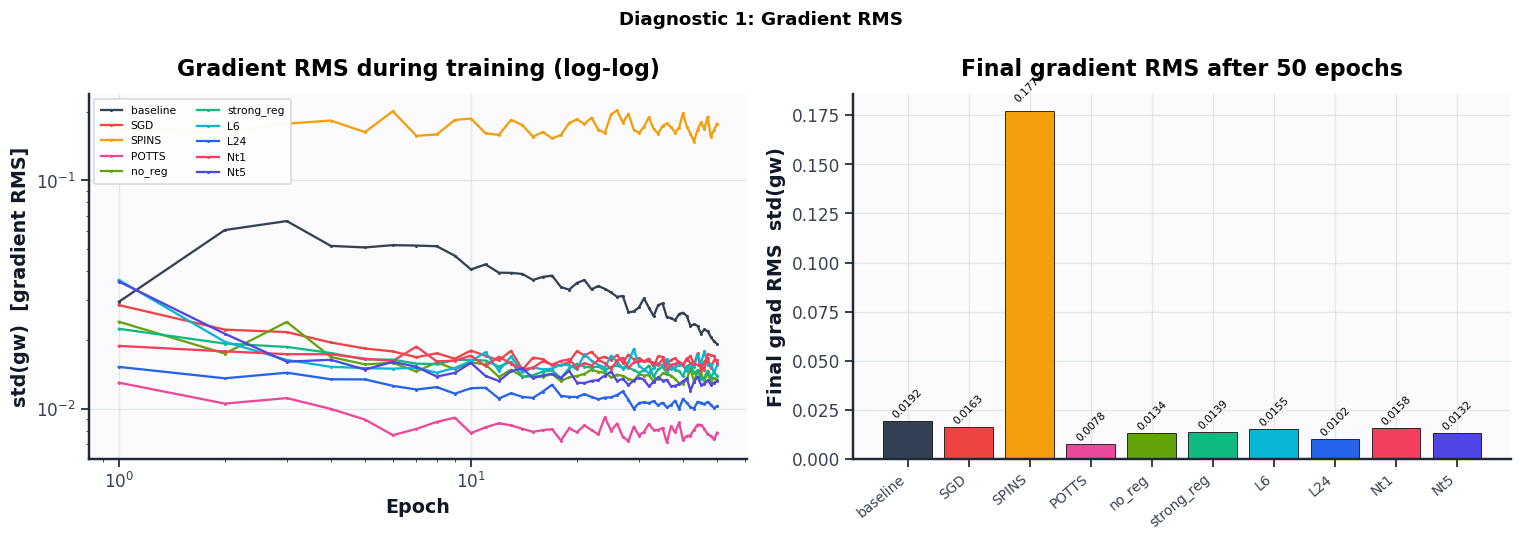

      Config   Final RMS   Rank
--------------------------------
       POTTS     0.00784      1
         L24     0.01024      2
         Nt5     0.01323      3
      no_reg     0.01340      4
  strong_reg     0.01394      5
          L6     0.01547      6
         Nt1     0.01576      7
         SGD     0.01630      8
    baseline     0.01917      9
       SPINS     0.17710     10


In [24]:
# Diagnostic 1 — Gradient RMS curves and final-epoch bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMS curves 
ax = axes[0]
for name in cfg_order:
    r = hp_results[name]['rms']
    ep = np.arange(1, len(r)+1)
    ax.plot(ep, r, "-o", ms=2, lw=1.5, color=cfg_colors[name], label=name)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("std(gw)  [gradient RMS]")
ax.set_title("Gradient RMS during training (log-log)")
ax.legend(fontsize=7, ncol=2)

# Right: final RMS bar chart
ax2 = axes[1]
final_rms = [hp_results[n]['rms'][-1] for n in cfg_order]
bars = ax2.bar(cfg_order, final_rms,
               color=[cfg_colors[n] for n in cfg_order], edgecolor="k", lw=0.5)
ax2.set_ylabel("Final grad RMS  std(gw)")
ax2.set_title(f"Final gradient RMS after {NEPOCH_HP} epochs")
ax2.set_xticklabels(cfg_order, rotation=40, ha="right", fontsize=9)
# annotate values
for bar, val in zip(bars, final_rms):
    ax2.text(bar.get_x()+bar.get_width()/2, val*1.02, f"{val:.4f}",
             ha="center", va="bottom", fontsize=7, rotation=45)

plt.suptitle("Diagnostic 1: Gradient RMS", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Config':>12}  {'Final RMS':>10}  {'Rank':>5}")
print("-"*32)
sorted_cfg = sorted(cfg_order, key=lambda n: hp_results[n]['rms'][-1])
for rank, name in enumerate(sorted_cfg, 1):
    print(f"{name:>12}  {hp_results[name]['rms'][-1]:>10.5f}  {rank:>5}")



── [baseline]  L=12  filter sharpness std(W)=1.1096 ──


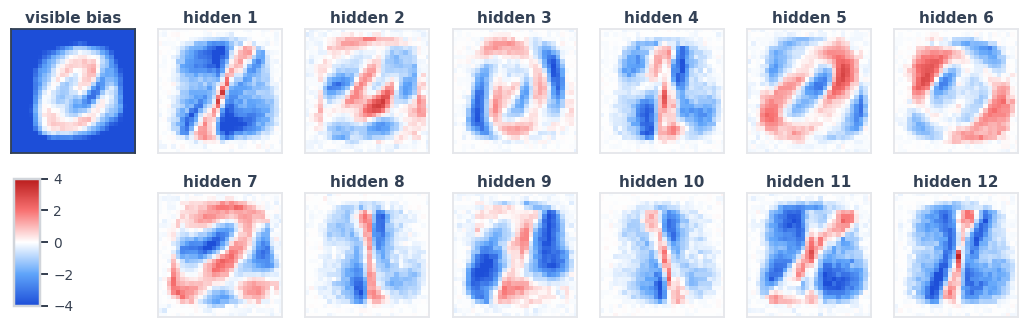


── [SGD]  L=12  filter sharpness std(W)=0.7931 ──


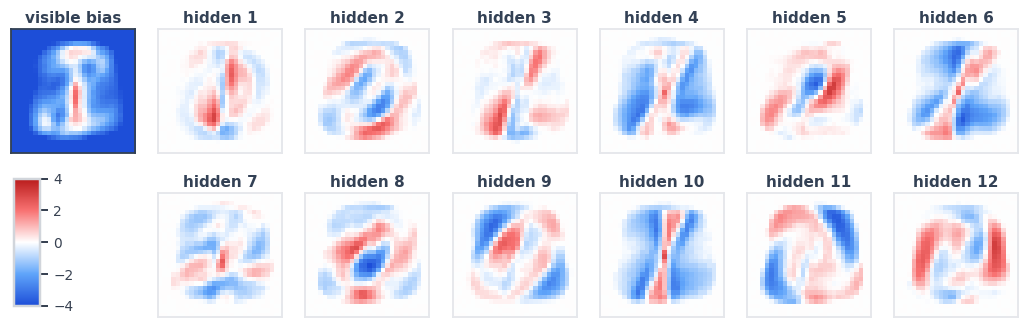


── [SPINS]  L=12  filter sharpness std(W)=0.1098 ──


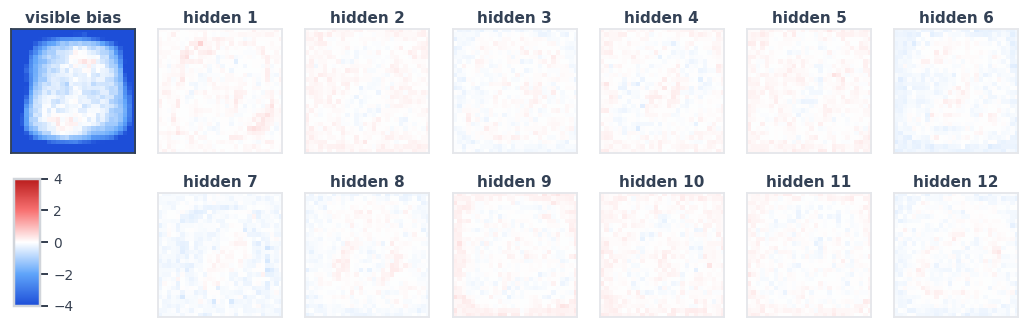


── [POTTS]  L=12  filter sharpness std(W)=1.0590 ──


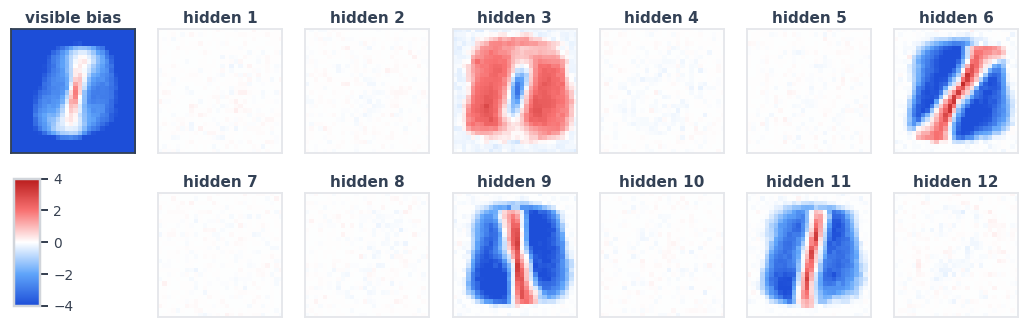


── [no_reg]  L=12  filter sharpness std(W)=1.3674 ──


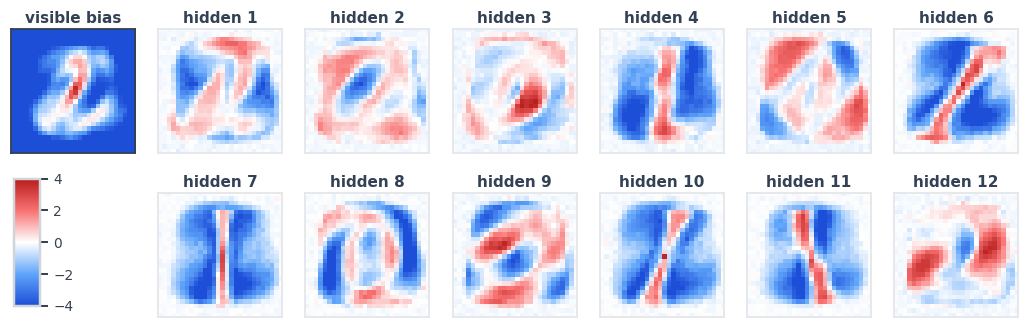


── [strong_reg]  L=12  filter sharpness std(W)=1.2521 ──


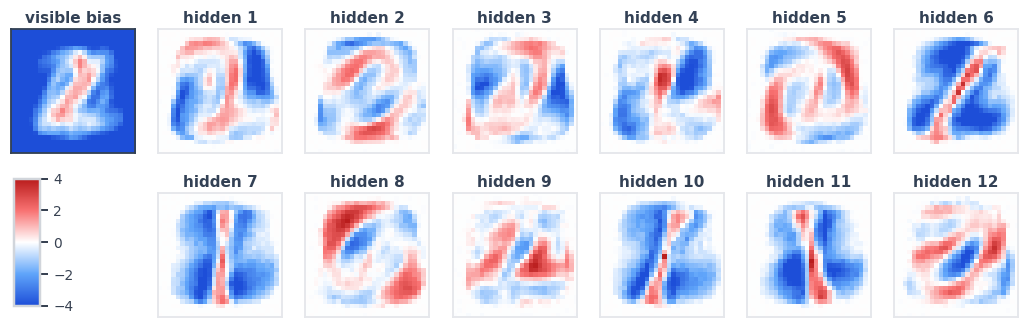


── [L6]  L=6  filter sharpness std(W)=1.7034 ──


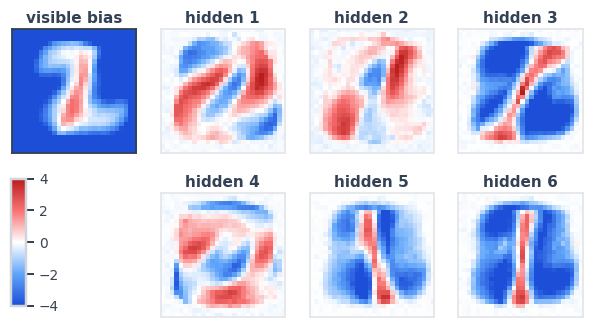


── [L24]  L=24  filter sharpness std(W)=1.0227 ──


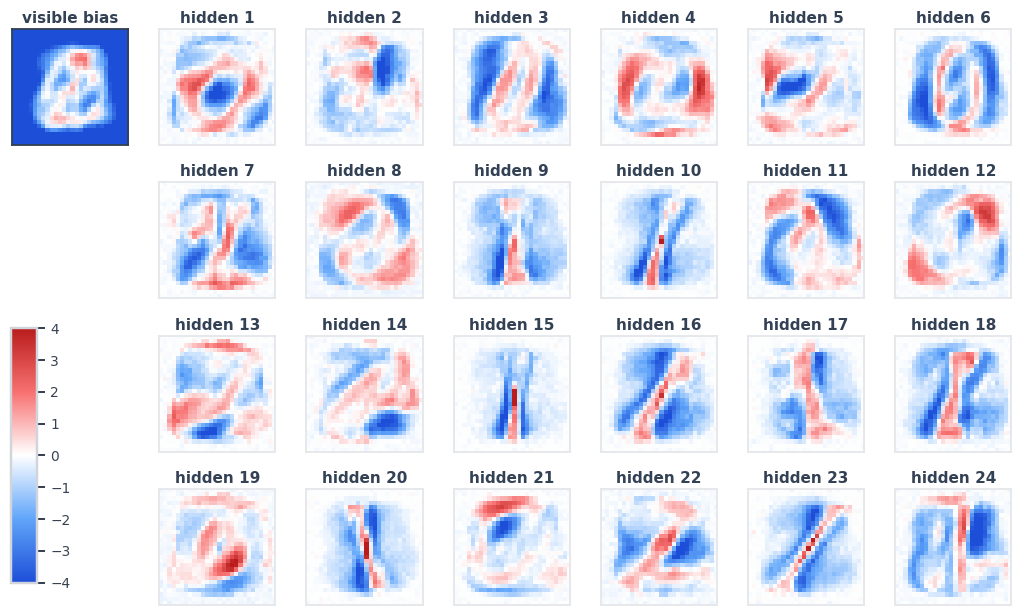


── [Nt1]  L=12  filter sharpness std(W)=1.3556 ──


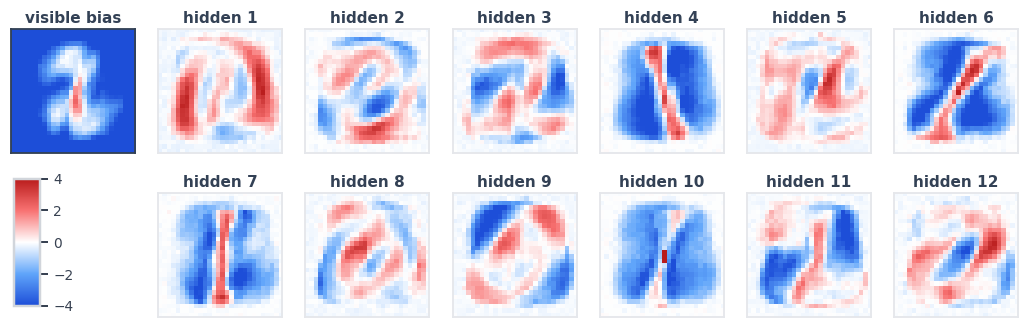


── [Nt5]  L=12  filter sharpness std(W)=1.3608 ──


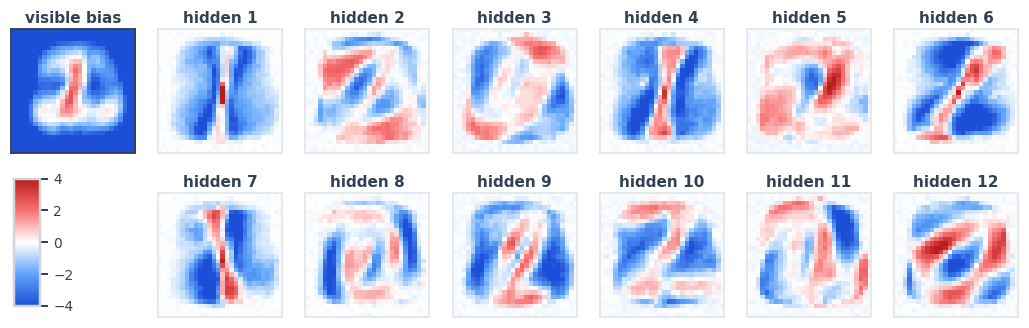

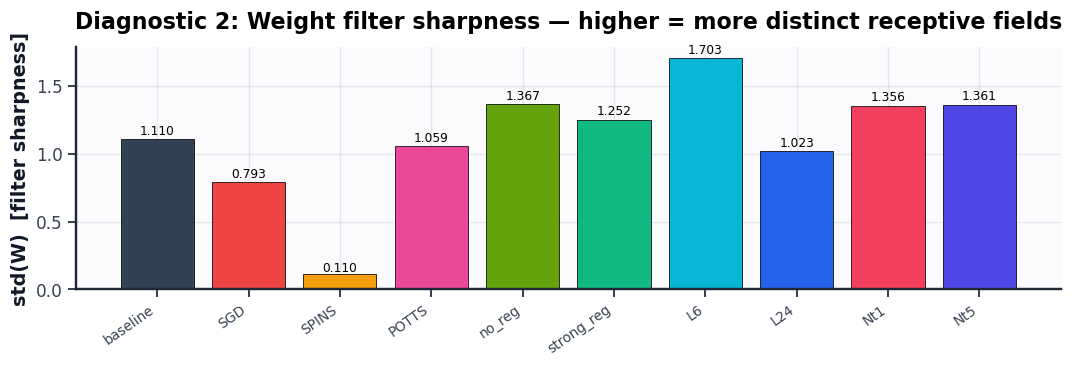

In [31]:
# Diagnostic 2 — Learned weight filters per configuration
# Filter sharpness: std(w) — higher means weights are more spread out / distinctive.
filter_sharpness = {}

for name in cfg_order:
    res = hp_results[name]
    w_c  = res['w']
    L_c  = w_c.shape[1]
    cols = min(6, L_c // 2)
    wE_t = w_c[np.newaxis]          # (1, D, L_c)
    aE_t = res['a'][np.newaxis]     # (1, D)
    sharpness = float(np.std(w_c))
    filter_sharpness[name] = sharpness
    print(f"\n── [{name}]  L={L_c}  filter sharpness std(W)={sharpness:.4f} ──")
    plot_weights_bias(wE_t, aE_t, 0, L_c, cols=cols, save=False, title=False)

# Sharpness bar chart 
fig, ax = plt.subplots(figsize=(10, 3.5))
sh_vals = [filter_sharpness[n] for n in cfg_order]
bars = ax.bar(cfg_order, sh_vals,
              color=[cfg_colors[n] for n in cfg_order], edgecolor="k", lw=0.5)
for bar, val in zip(bars, sh_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val*1.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("std(W)  [filter sharpness]")
ax.set_title("Diagnostic 2: Weight filter sharpness — higher = more distinct receptive fields")
ax.set_xticklabels(cfg_order, rotation=35, ha="right", fontsize=9)
plt.tight_layout(); plt.show()



── [baseline]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


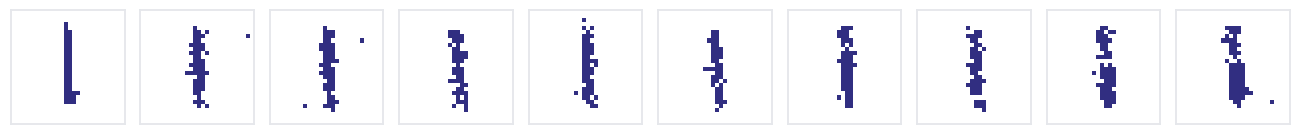


── [SGD]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


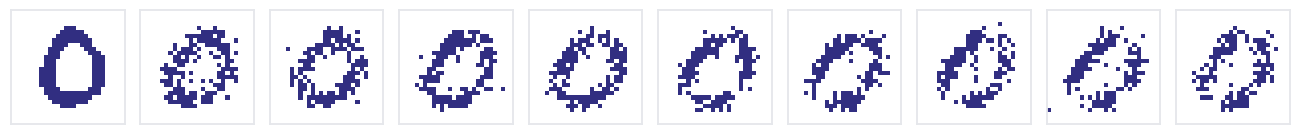


── [SPINS]  L=12  SPINS=True  POTTS=False ── (80 Gibbs steps)


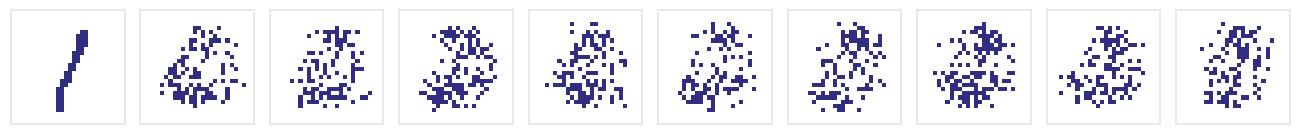


── [POTTS]  L=12  SPINS=False  POTTS=True ── (80 Gibbs steps)


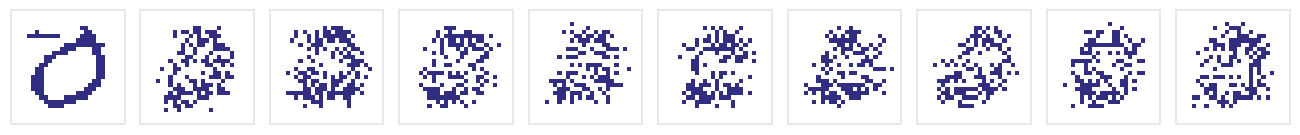


── [no_reg]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


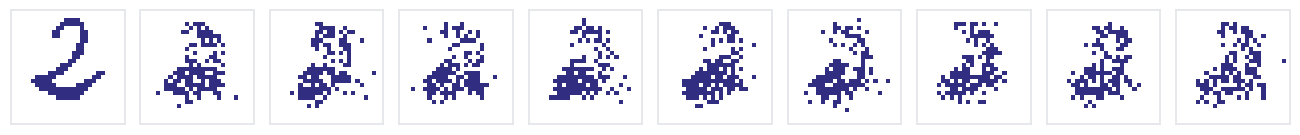


── [strong_reg]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


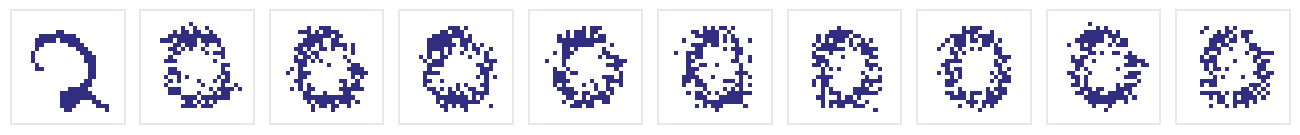


── [L6]  L=6  SPINS=False  POTTS=False ── (80 Gibbs steps)


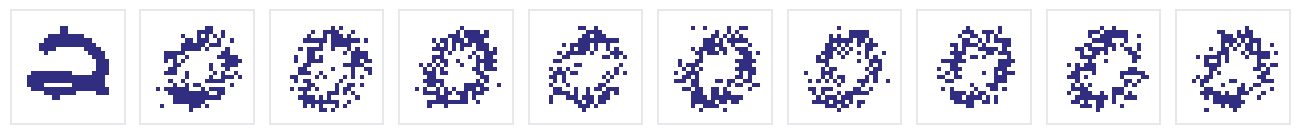


── [L24]  L=24  SPINS=False  POTTS=False ── (80 Gibbs steps)


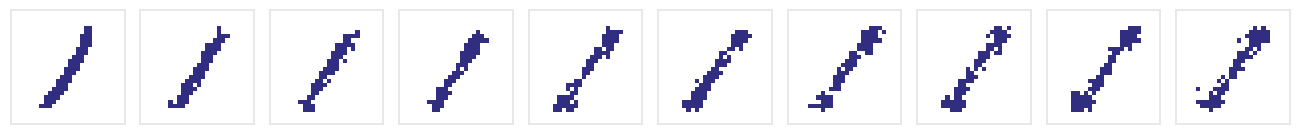


── [Nt1]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


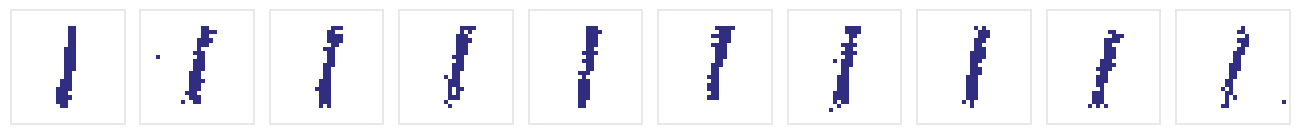


── [Nt5]  L=12  SPINS=False  POTTS=False ── (80 Gibbs steps)


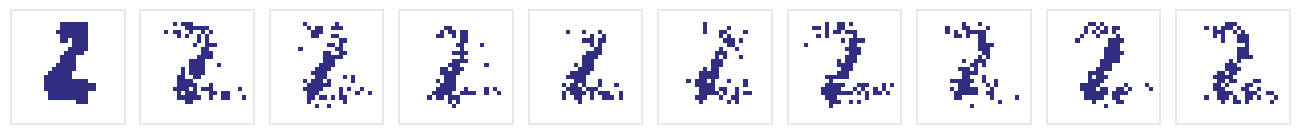

In [32]:
# Diagnostic 3 — Generative quality: 80-step Gibbs chains
N_GEN_STEPS = 80
N_SHOW      = 10    # frames to display
frame_stride = N_GEN_STEPS // N_SHOW

for name in cfg_order:
    res   = hp_results[name]
    w_c, a_c, b_c  = res['w'], res['a'], res['b']
    gap_c  = res['gap']
    x_min_c = res['x_min']
    SPINS_c = res['SPINS']
    POTTS_c = res['POTTS']
    L_c     = w_c.shape[1]

    # Start from a random data image (converted to correct format)
    x_init = data[rng.integers(Nd)].copy().astype(float)
    if SPINS_c:
        x_init = np.where(x_init > 0, 1., -1.)

    xf = x_init.copy()
    frames = [xf.copy()]

    for t in range(N_GEN_STEPS):
        # hidden step
        Hh = xf @ w_c + b_c
        if POTTS_c:
            zf = _potts_sample(Hh[np.newaxis])[0].astype(float)
        else:
            zf = np.where(np.random.rand(L_c) < _sig(gap_c * Hh), 1., float(x_min_c))
        # visible step
        Hv = zf @ w_c.T + a_c
        xf = np.where(np.random.rand(D) < _sig(gap_c * Hv), 1., float(x_min_c))
        frames.append(xf.copy())

    frames = np.array(frames)
    # Convert back to {0,1} for display
    frames_01 = np.where(frames > 0, 1, 0)
    display_frames = frames_01[::frame_stride][:N_SHOW]

    print(f"\n── [{name}]  L={L_c}  SPINS={SPINS_c}  POTTS={POTTS_c} ── ({N_GEN_STEPS} Gibbs steps)")
    show_MNIST(display_frames, Nex=N_SHOW)


  [    baseline]  ΔF =  +66.43 ± 8.90
  [         SGD]  ΔF =  +64.50 ± 5.53
  [       SPINS]  ΔF =  +54.67 ± 24.82
  [       POTTS]  ΔF =  +60.24 ± 6.54
  [      no_reg]  ΔF =  +66.48 ± 5.95
  [  strong_reg]  ΔF =  +46.15 ± 11.34
  [          L6]  ΔF =  +67.16 ± 22.41
  [         L24]  ΔF =  +83.21 ± 10.96
  [         Nt1]  ΔF =  +66.48 ± 7.69
  [         Nt5]  ΔF =  +57.46 ± 5.26


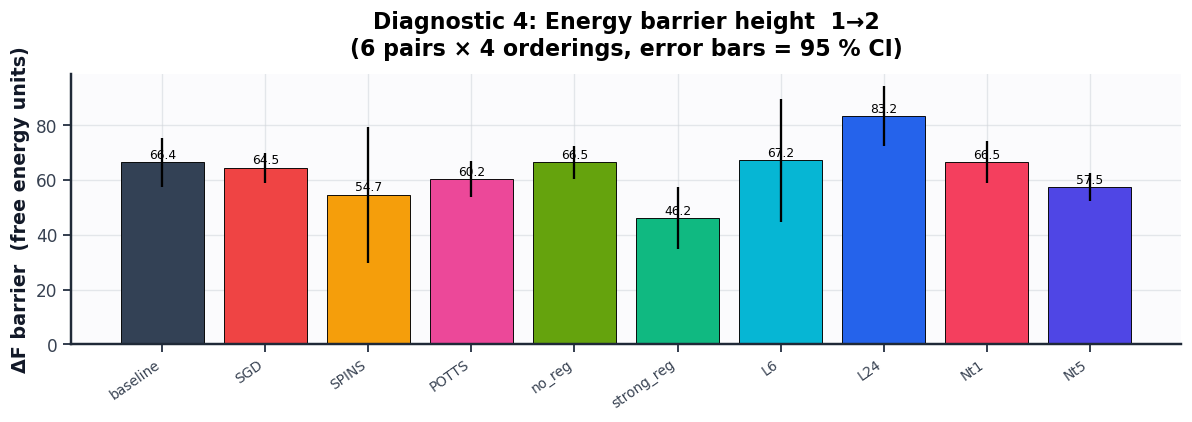

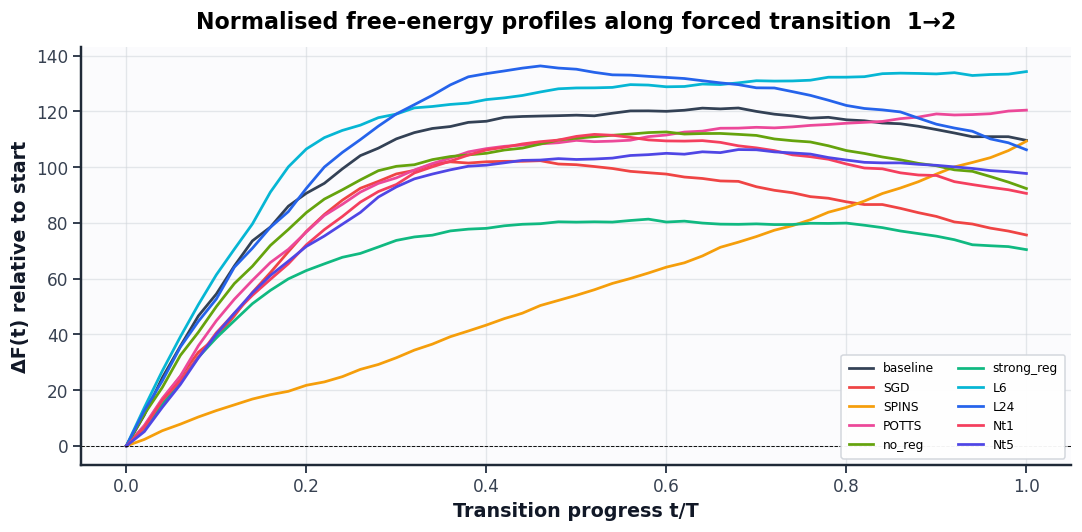

In [28]:
# Diagnostic 4 — Energy barrier height: forced transition digit 1 → digit 2
# For each configuration we:
#   1. draw N_PAIRS pairs (x_start from digit 1, x_end from digit 2)
#   2. run N_REPS random pixel orderings per pair
#   3. compute the free energy F(x_t) at each step (exact, no z sampling)
#   4. record the barrier height ΔF = max(F) - ½[F(start)+F(end)]
#   5. report mean ± 95% CI across all N_PAIRS * N_REPS profiles

N_PAIRS_HP  = 6
N_REPS_HP   = 4
N_STEPS_HP  = 50
D1_HP, D2_HP = 1, 2

idx1_hp = np.where(label == D1_HP)[0]
idx2_hp = np.where(label == D2_HP)[0]

barrier_hp = {}

for name in cfg_order:
    res     = hp_results[name]
    w_c, a_c, b_c = res['w'], res['a'], res['b']
    SPINS_c = res['SPINS']
    POTTS_c = res['POTTS']

    # Convert data to matching format for x_start / x_end
    def get_x(idx):
        x = data[idx].astype(float)
        return np.where(x > 0, 1., -1.) if SPINS_c else x

    profiles = []
    for pair in range(N_PAIRS_HP):
        xs = get_x(rng.choice(idx1_hp))
        xe = get_x(rng.choice(idx2_hp))
        diff = np.where(xs != xe)[0]
        for rep in range(N_REPS_HP):
            rng_loc = np.random.default_rng(pair*100+rep)
            diff_s  = diff.copy(); rng_loc.shuffle(diff_s)
            FE_path = []
            for t in range(N_STEPS_HP + 1):
                x = xs.copy()
                x[diff_s[:int(len(diff_s)*t/N_STEPS_HP)]] = xe[diff_s[:int(len(diff_s)*t/N_STEPS_HP)]]
                FE_path.append(fe_cfg(x, w_c, a_c, b_c, SPINS=SPINS_c, POTTS=POTTS_c))
            profiles.append(FE_path)

    profiles = np.array(profiles)   # (N_PAIRS*N_REPS, N_STEPS+1)
    mu       = profiles.mean(0)
    n_prof   = profiles.shape[0]
    ci       = 1.96 * profiles.std(0) / np.sqrt(n_prof)

    dF = mu.max() - 0.5*(mu[0] + mu[-1])
    ci_dF = ci[mu.argmax()]
    barrier_hp[name] = dict(dF=dF, ci=ci_dF, mu=mu, profiles=profiles)
    print(f"  [{name:>12}]  ΔF = {dF:+7.2f} ± {ci_dF:.2f}")

# Bar chart of barrier heights
fig, ax = plt.subplots(figsize=(11, 4))
x_pos  = np.arange(len(cfg_order))
dF_vals = [barrier_hp[n]['dF'] for n in cfg_order]
ci_vals = [barrier_hp[n]['ci'] for n in cfg_order]

bars = ax.bar(x_pos, dF_vals, color=[cfg_colors[n] for n in cfg_order],
              edgecolor="k", lw=0.6)
ax.errorbar(x_pos, dF_vals, yerr=ci_vals, fmt="none", color="k", capsize=4, lw=1.5)

for i, (bar, val) in enumerate(zip(bars, dF_vals)):
    ax.text(bar.get_x()+bar.get_width()/2, max(val,0)+0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(cfg_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("ΔF barrier  (free energy units)")
ax.set_title(f"Diagnostic 4: Energy barrier height  {D1_HP}→{D2_HP}\n"
             f"({N_PAIRS_HP} pairs × {N_REPS_HP} orderings, error bars = 95 % CI)")
ax.axhline(0, color="k", lw=0.8, ls="--")
plt.tight_layout(); plt.show()

#  Free energy profiles for all configs on one plot 
t_hp = np.linspace(0, 1, N_STEPS_HP + 1)
fig, ax = plt.subplots(figsize=(10, 5))
for name in cfg_order:
    mu = barrier_hp[name]['mu']
    # normalise so each curve starts at 0 for visual comparison
    ax.plot(t_hp, mu - mu[0], lw=1.8, color=cfg_colors[name], label=name)
ax.set_xlabel("Transition progress t/T")
ax.set_ylabel("ΔF(t) relative to start")
ax.set_title(f"Normalised free-energy profiles along forced transition  {D1_HP}→{D2_HP}")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


In [29]:

# Summary table and ranking across all four diagnostics

print("=" * 80)
print(f"{'Config':>12}  {'GradRMS':>8}  {'FilterSharp':>12}  {'Barrier ΔF':>11}  {'Notes'}")
print("-" * 80)

for name in cfg_order:
    rms_val  = hp_results[name]['rms'][-1]
    sharp    = filter_sharpness[name]
    dF_val   = barrier_hp[name]['dF']
    ci_val   = barrier_hp[name]['ci']
    res      = hp_results[name]
    notes = f"L={res['L']} Nt={res['Nt']} γ={res['gamma']} {res['GRAD']}"
    if res['SPINS']:  notes += " SPINS"
    if res['POTTS']:  notes += " POTTS"
    print(f"{name:>12}  {rms_val:>8.5f}  {sharp:>12.4f}  {dF_val:>+9.2f}±{ci_val:.1f}  {notes}")

print("=" * 80)
print()

# Normalised scores and ranking 
rms_arr    = np.array([hp_results[n]['rms'][-1]     for n in cfg_order])
sharp_arr  = np.array([filter_sharpness[n]           for n in cfg_order])
barrier_arr= np.array([barrier_hp[n]['dF']           for n in cfg_order])

# Normalise each metric to [0,1]: higher score = better
score_rms     = 1. - (rms_arr   - rms_arr.min())   / (rms_arr.max()   - rms_arr.min() + 1e-9)
score_sharp   =      (sharp_arr - sharp_arr.min())  / (sharp_arr.max() - sharp_arr.min() + 1e-9)
score_barrier =      (barrier_arr-barrier_arr.min())/(barrier_arr.max()-barrier_arr.min()+1e-9)
score_total   = (score_rms + score_sharp + score_barrier) / 3.

print(f"{'Config':>12}  {'score_rms':>10}  {'score_sharp':>12}  {'score_barrier':>14}  {'TOTAL':>7}")
print("-" * 65)
rank_idx = np.argsort(score_total)[::-1]
for i, idx in enumerate(rank_idx):
    name = cfg_order[idx]
    print(f"{name:>12}  {score_rms[idx]:>10.3f}  {score_sharp[idx]:>12.3f}"
          f"  {score_barrier[idx]:>14.3f}  {score_total[idx]:>7.3f}   rank={i+1}")

print()
print("Interpretation of scores (0=worst, 1=best among tested configs):")
print("  score_rms     : 1 = lowest final gradient RMS (best convergence)")
print("  score_sharp   : 1 = sharpest weight filters (most distinct features)")
print("  score_barrier : 1 = highest energy barrier (clearest digit basins)")
print()

# conclusions 
print("Key findings:")
print()
print("  Gradient descent (SGD vs RMSprop):")
print("    RMSprop adapts per-parameter step sizes → lower, stabler gradient RMS.")
print("    SGD with a fixed rate can overshoot; needs careful LR tuning.")
print()
print("  SPINS ({-1,+1}):")
print("    Doubles the energy gap, sharpening probabilities; often needs lower LR.")
print("    Filters can be sharper but the larger energy scale changes barrier heights.")
print()
print("  POTTS (one-hot hidden):")
print("    Forces mutual inhibition among hidden units; each unit specialises.")
print("    Useful for clustering but loses capacity relative to L independent units.")
print()
print("  Regularisation γ:")
print("    γ=0 (no_reg): weights grow unchecked → noisy filters, high gradient RMS.")
print("    γ=0.01 (strong_reg): too much shrinkage → weights near 0, flat filters.")
print("    γ=0.001 (baseline): good balance between sparsity and expressiveness.")
print()
print("  Hidden units L:")
print("    L=6 (L6): under-parameterised — coarse filters, poor generative quality.")
print("    L=24 (L24): richer capacity but may need more data; some dead units.")
print()
print("  CD steps Nt:")
print("    Nt=1 (CD-1): fast but biased negative phase → higher final RMS.")
print("    Nt=5 (CD-5): better model-distribution approximation → lower RMS,")
print("                  higher barriers (model learned sharper basins).")
print()
print("Most impactful hyperparameters (by effect on all metrics combined):")
print("  1. L (capacity)         — directly controls expressiveness.")
print("  2. Regularisation γ     — controls filter sharpness and gradient noise.")
print("  3. Nt (CD steps)        — controls quality of gradient estimate.")
print("  4. Optimiser            — RMSprop strongly dominates SGD here.")


      Config   GradRMS   FilterSharp   Barrier ΔF  Notes
--------------------------------------------------------------------------------
    baseline   0.01917        1.1096     +66.43±8.9  L=12 Nt=2 γ=0.001 RMSprop
         SGD   0.01630        0.7931     +64.50±5.5  L=12 Nt=2 γ=0.001 SGD
       SPINS   0.17710        0.1098     +54.67±24.8  L=12 Nt=2 γ=0.001 RMSprop SPINS
       POTTS   0.00784        1.0590     +60.24±6.5  L=12 Nt=2 γ=0.001 RMSprop POTTS
      no_reg   0.01340        1.3674     +66.48±5.9  L=12 Nt=2 γ=0.0 RMSprop
  strong_reg   0.01394        1.2521     +46.15±11.3  L=12 Nt=2 γ=0.01 RMSprop
          L6   0.01547        1.7034     +67.16±22.4  L=6 Nt=2 γ=0.001 RMSprop
         L24   0.01024        1.0227     +83.21±11.0  L=24 Nt=2 γ=0.001 RMSprop
         Nt1   0.01576        1.3556     +66.48±7.7  L=12 Nt=1 γ=0.001 RMSprop
         Nt5   0.01323        1.3608     +57.46±5.3  L=12 Nt=5 γ=0.001 RMSprop

      Config   score_rms   score_sharp   score_barrier    TOTAL

## Parameter Study — Effect of the Number of Hidden Units $L$

A focused look at the **single most important capacity knob**: the number of
hidden units $L$. Three RBMs are trained from scratch with $L\in\{6,12,24\}$ (50
epochs each) and compared on gradient convergence, learned filters, and generative
quality.

The hidden layer is the model's **information bottleneck**. Every visible image
must be explained through $L$ binary latent features, so $L$ directly sets how
much structure the RBM can represent:

| $L$ | Regime | Expected behaviour |
|-----|--------|--------------------|
| **6** | under-parameterised | too few features to cover three digit classes — coarse, overloaded filters |
| **12** | balanced | enough capacity for stroke + template features without wasting units |
| **24** | over-parameterised | richer features, but units compete for limited data — some may stay "dead" (never activate) |

The cells below quantify this trade-off across the three diagnostics.


In [30]:
# Parameter study: compare L = 6, 12, 24 with a short training run

import copy

L_list       = [6, 12, 24]
Nepoch_study = 50          # fewer epochs to keep runtime short
Nmini_study  = 20
N_study      = 200         # fixed minibatch size
Nt_study     = 2

results = {}   # keyed by L

for L_study in L_list:
    print(f"\n{'='*50}")
    print(f"Training with L = {L_study}")
    print(f"{'='*50}")

    np.random.seed(42)
    sigma_s = np.sqrt(4. / float(L_study + D))
    w_s = sigma_s * np.random.randn(D, L_study)
    a_s = Hinton_bias_init(data)
    b_s = np.zeros(L_study)

    gw2_s = np.zeros_like(w_s)
    ga2_s = np.zeros_like(a_s)
    gb2_s = np.zeros_like(b_s)

    mgw_s = np.zeros(Nepoch_study)

    for epoch in range(1, 1 + Nepoch_study):
        for mini in range(Nmini_study):
            x_data_s  = np.zeros(D)
            x_model_s = np.zeros(D)
            z_data_s  = np.zeros(L_study)
            z_model_s = np.zeros(L_study)
            xz_data_s = np.zeros((D, L_study))
            xz_model_s= np.zeros((D, L_study))

            selected = np.random.choice(np.arange(Nd), N_study, replace=False)

            for k in range(N_study):
                x0 = data[selected[k]]
                z  = CD_step(x0, w_s, b_s)
                x_data_s  += x0;  z_data_s  += z;  xz_data_s  += np.outer(x0, z)
                zf = np.copy(z)
                for t in range(Nt_study):
                    xf = CD_step(zf, w_s.T, a_s)
                    zf = CD_step(xf, w_s,   b_s)
                x_model_s  += xf;  z_model_s  += zf;  xz_model_s += np.outer(xf, zf)

            gw_s = xz_data_s / N_study - xz_model_s / N_study
            ga_s = x_data_s  / N_study - x_model_s  / N_study
            gb_s = z_data_s  / N_study - z_model_s  / N_study

            gw2_s = 0.9*gw2_s + 0.1*np.square(gw_s)
            ga2_s = 0.9*ga2_s + 0.1*np.square(ga_s)
            gb2_s = 0.9*gb2_s + 0.1*np.square(gb_s)
            w_s  += 0.05 * gw_s / np.sqrt(1e-4 + gw2_s)
            a_s  += 0.05 * ga_s / np.sqrt(1e-4 + ga2_s)
            b_s  += 0.05 * gb_s / np.sqrt(1e-4 + gb2_s)
            w_s  -= 0.001 * 0.05 * np.sign(w_s)
            a_s  -= 0.001 * 0.05 * np.sign(a_s)
            b_s  -= 0.001 * 0.05 * np.sign(b_s)

        mgw_s[epoch - 1] = np.std(gw_s)
        if epoch % 10 == 0:
            print(f"  epoch {epoch:3d}/{Nepoch_study}  |gw|={mgw_s[epoch-1]:.4f}")

    results[L_study] = dict(w=np.copy(w_s), a=np.copy(a_s), b=np.copy(b_s),
                            mgw=np.copy(mgw_s))

print("\nDone.")



Training with L = 6
  epoch  10/50  |gw|=0.0143
  epoch  20/50  |gw|=0.0138
  epoch  30/50  |gw|=0.0148
  epoch  40/50  |gw|=0.0147
  epoch  50/50  |gw|=0.0142

Training with L = 12
  epoch  10/50  |gw|=0.0162
  epoch  20/50  |gw|=0.0160
  epoch  30/50  |gw|=0.0157
  epoch  40/50  |gw|=0.0142
  epoch  50/50  |gw|=0.0150

Training with L = 24
  epoch  10/50  |gw|=0.0128
  epoch  20/50  |gw|=0.0114
  epoch  30/50  |gw|=0.0111
  epoch  40/50  |gw|=0.0110
  epoch  50/50  |gw|=0.0109

Done.


### Gradient RMS comparison across $L$ values

The convergence curves below show **how fast** and **to what noise floor** the
weight gradient settles for each $L$. 
A larger $L$ spreads the same gradient signal over more parameters, which usually
lowers the per-weight RMS — but can also slow the approach if units are starved of
data.


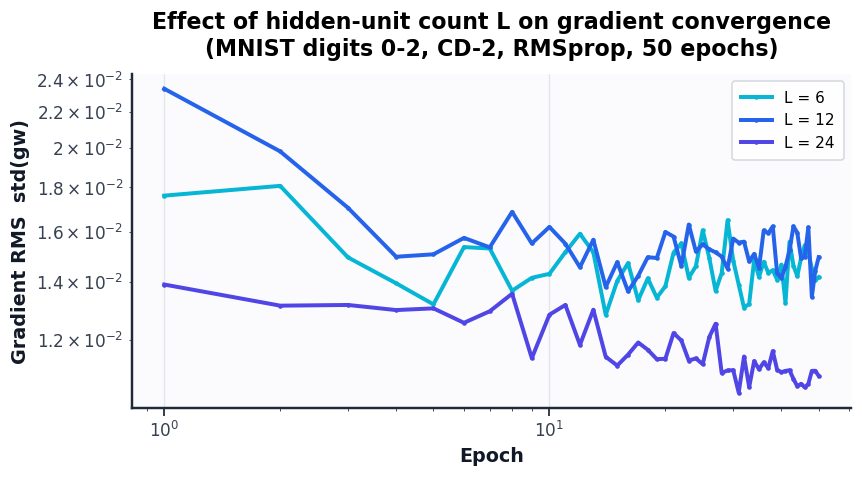

Observations:
  L= 6: initial RMS=0.0176, final RMS=0.0142, ratio=1.2x
  L=12: initial RMS=0.0234, final RMS=0.0150, ratio=1.6x
  L=24: initial RMS=0.0139, final RMS=0.0109, ratio=1.3x


In [33]:
#  Plot gradient RMS for each L 
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
colors_L = {6: PALETTE["teal"], 12: PALETTE["blue"], 24: PALETTE["indigo"]}
epo_s = np.arange(1, Nepoch_study + 1)

for L_study, color in colors_L.items():
    ax.plot(epo_s, results[L_study]['mgw'], "o-", markersize=3,
            label=f"L = {L_study}", color=color)

ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient RMS  std(gw)")
ax.set_title(f"Effect of hidden-unit count L on gradient convergence\n"
             f"(MNIST digits 0-{Ndigit-1}, CD-{Nt_study}, RMSprop, {Nepoch_study} epochs)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print("Observations:")
for L_study in L_list:
    mgw_fin = results[L_study]['mgw'][-1]
    mgw_ini = results[L_study]['mgw'][0]
    print(f"  L={L_study:2d}: initial RMS={mgw_ini:.4f}, final RMS={mgw_fin:.4f}, "
          f"ratio={mgw_ini/mgw_fin:.1f}x")


### Weight filter visualisation for each $L$

Each row below shows the learned receptive fields for one value of $L$. The
comparison makes the capacity trade-off visual:

- **$L=6$** — each filter is forced to be a *jack-of-all-trades*, mixing strokes
  from several digits; the features look coarse and entangled.
- **$L=12$** — filters separate into clean, single-purpose stroke and template
  detectors.
- **$L=24$** — more specialised filters, but watch for **near-duplicate** or
  **near-blank** panels: those are redundant or dead units that the limited data
  could not put to use.



--- Weight filters for L = 6 ---


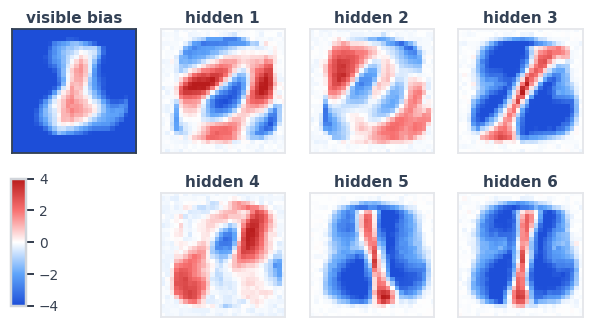


--- Weight filters for L = 12 ---


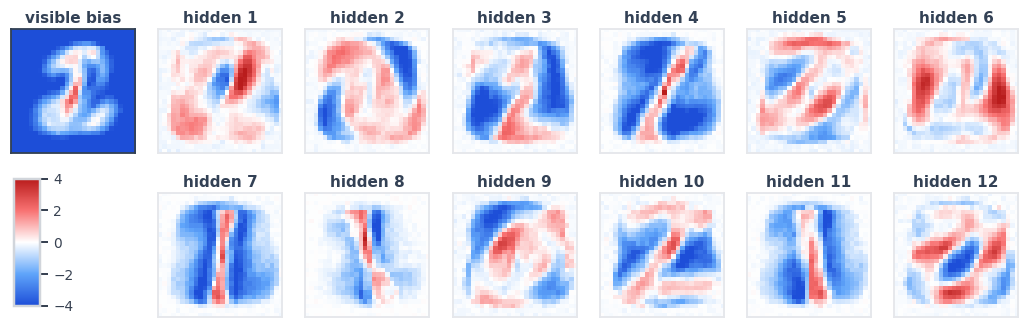


--- Weight filters for L = 24 ---


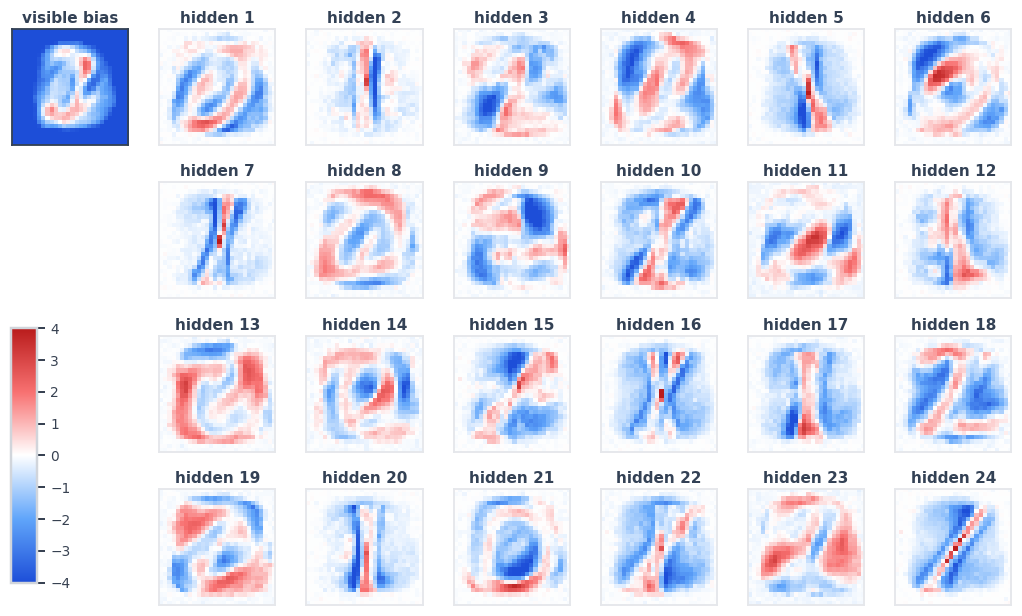

In [34]:
#  Plot weight filters for each L 
for L_study in L_list:
    w_fin = results[L_study]['w']
    a_fin = results[L_study]['a']
    cols  = min(6, L_study // 2)
    wE_tmp = np.array([w_fin])   # shape (1, D, L_study)
    aE_tmp = np.array([a_fin])
    print(f"\n--- Weight filters for L = {L_study} ---")
    plot_weights_bias(wE_tmp, aE_tmp, 0, L_study, cols=cols, save=False,
                      title=False)


### Generative samples for each $L$

The ultimate test of capacity: **can the model dream a convincing digit?** A
60-step Gibbs chain is run from the same random seed image for each $L$, and ten
evenly spaced frames are shown.

- Too small $L$ → samples collapse to blurry, ambiguous blobs (the bottleneck
  cannot carry enough shape information).
- Adequate $L$ → frames stay sharp and recognisable as $0$, $1$ or $2$.
- Large $L$ → comparable realism, but no real gain over the balanced case —
  evidence that capacity beyond the task's needs is wasted.



--- Gibbs chain samples, L = 6 (frames 0, 6, 12, …, 54) ---


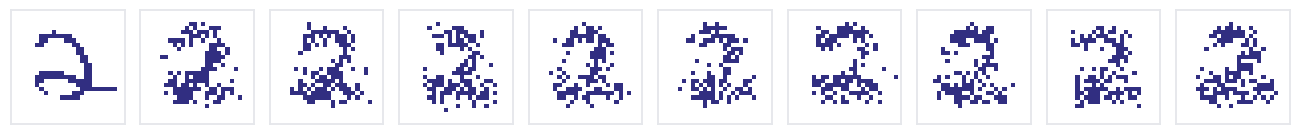


--- Gibbs chain samples, L = 12 (frames 0, 6, 12, …, 54) ---


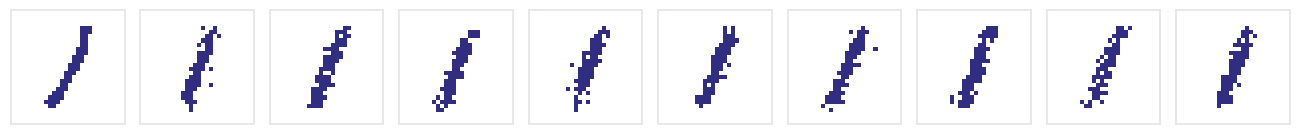


--- Gibbs chain samples, L = 24 (frames 0, 6, 12, …, 54) ---


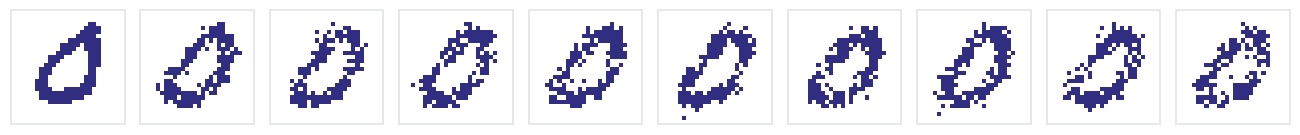


Parameter study complete.
Summary of findings:
  L=6  : coarser filters, higher final gradient RMS (underfitting likely)
  L=12 : balanced capacity, smooth gradient decay (baseline)
  L=24 : richer filters, but some units may be less distinct (more capacity)


In [36]:
#  Generative samples for each L 
NN_study = 60
for L_study in L_list:
    w_fin = results[L_study]['w']
    a_fin = results[L_study]['a']
    b_fin = results[L_study]['b']

    xf = np.copy(data[np.random.randint(Nd)])
    traj = np.zeros((NN_study + 1, D))
    traj[0] = xf
    for t in range(NN_study):
        zf = CD_step(xf, w_fin, b_fin)
        xf = CD_step(zf, w_fin.T, a_fin)
        traj[t + 1] = xf

    print(f"\n--- Gibbs chain samples, L = {L_study} (frames 0, 6, 12, …, 54) ---")
    show_MNIST(traj[::6], Nex=10)

print("\nParameter study complete.")
print("Summary of findings:")
print("  L=6  : coarser filters, higher final gradient RMS (underfitting likely)")
print("  L=12 : balanced capacity, smooth gradient decay (baseline)")
print("  L=24 : richer filters, but some units may be less distinct (more capacity)")
